# **Laboratorio 6:** Análisis de redes sociales

Universidad del Valle de Guatemala  |  Data Science (Sección 20)

> **Grupo #7:** Marco Carbajal (23025), Carlos Angel (23010) y Diego Monroy (23318)

In [1]:
import ast
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms import bipartite
from scipy.stats import spearmanr

import emoji
import nltk
import spacy

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 70)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False})
RUTA = '.'

### **1.** Carga, comprensión e integración de los datos

#### **1.1** Carga de los archivos

In [2]:
videos = pd.read_csv(f'{RUTA}/youtube_videos.csv')
comentarios = pd.read_csv(f'{RUTA}/youtube_comments.csv')

print('videos:', videos.shape)
print('comentarios:', comentarios.shape)
videos.head(3)

videos: (293, 20)
comentarios: (406, 17)


,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana e...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatem...,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en ...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatema...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en ...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio d...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio d...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatem...,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxi...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachic...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéx...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [3]:
comentarios.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la ...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | yout...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad de las reuniones vi...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | yout...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


#### **1.2** Unidad de observación, llave primaria y variables relevantes

En `youtube_videos.csv` la unidad de observación es el video y la llave primaria es `video_id`, que no presenta duplicados en las 293 filas. Las variables relevantes para este laboratorio son `channel_id` (identificador estable del canal), `title` y `description` para el análisis temático, `view_count` para popularidad, `category`, `source_query` y `source_group` para reconstruir el muestreo, y `publish_date` como única marca temporal absoluta.

En `youtube_comments.csv` la unidad de observación es el comentario y la llave primaria es `comment_id`, también sin duplicados en las 406 filas. Las variables relevantes son `video_id` como llave foránea, `author_channel_id` para identificar al autor, `text` para el contenido, `like_count_text` y `reply_count` como medidas de recepción, y `channel_id` que identifica al canal dueño del video comentado, no al autor.

In [4]:
llaves = pd.DataFrame({
    'archivo': ['videos', 'comentarios'],
    'filas': [len(videos), len(comentarios)],
    'columnas': [videos.shape[1], comentarios.shape[1]],
    'llave': ['video_id', 'comment_id'],
    'llave_duplicada': [videos.video_id.duplicated().sum(), comentarios.comment_id.duplicated().sum()],
    'filas_duplicadas': [videos.duplicated().sum(), comentarios.duplicated().sum()],
})
llaves

,archivo,filas,columnas,llave,llave_duplicada,filas_duplicadas
0,videos,293,20,video_id,0,0
1,comentarios,406,17,comment_id,0,0


#### **1.3** Relación entre canal, video, autor, comentario, categoría y consulta

La estructura es jerárquica en dos niveles. Un canal, identificado por `channel_id`, publica varios videos: hay 97 canales para 293 videos, con una mediana de 1 video por canal y un máximo de 32. Cada video puede recibir varios comentarios, y cada comentario tiene un autor identificado por `author_channel_id`, que es un identificador de cuenta distinto del canal que publicó el video.

La categoría es un atributo del video asignado por YouTube, no del comentario ni del autor, aunque se hereda al unir las tablas. La consulta de búsqueda es un atributo del procedimiento de recolección: `source_query` describe cómo se encontró el registro y `source_group` clasifica la estrategia usada. Ninguna de las dos describe el tema del video de forma confiable, por lo que se usan para auditar la cobertura y no como variable temática.

Un punto importante es que autores de comentarios y canales de video son conjuntos disjuntos en estos datos: ninguno de los 332 `author_channel_id` aparece como `channel_id` de un video. La red no mezcla ambos roles.

In [5]:
print('canales:', videos.channel_id.nunique(), '| videos por canal (mediana, max):',
      int(videos.channel_id.value_counts().median()), videos.channel_id.value_counts().max())
print('autores:', comentarios.author_channel_id.nunique())
print('autores que también son canales de video:',
      len(set(comentarios.author_channel_id) & set(videos.channel_id)))

canales: 97 | videos por canal (mediana, max): 1 32
autores: 332
autores que también son canales de video: 0


#### **1.4** Integración por `video_id`

In [6]:
integrado = comentarios.merge(
    videos[['video_id', 'channel_id', 'channel_name', 'title', 'view_count',
            'category', 'source_group', 'source_query', 'publish_date']],
    on='video_id', how='left', suffixes=('_com', '_vid'))

asociados = integrado.title.notna().sum()
print(f'comentarios asociados a un video: {asociados} de {len(comentarios)} '
      f'({asociados / len(comentarios):.1%})')
print('videos distintos con comentarios:', comentarios.video_id.nunique(),
      f'de {len(videos)} ({comentarios.video_id.nunique() / len(videos):.1%})')
print('canales distintos con comentarios:', comentarios.channel_id.nunique())

comentarios asociados a un video: 406 de 406 (100.0%)
videos distintos con comentarios: 19 de 293 (6.5%)
canales distintos con comentarios: 8


In [7]:
coincidencias = pd.Series({
    'channel_id igual en ambas tablas': (integrado.channel_id_com == integrado.channel_id_vid).mean(),
    'channel_name igual en ambas tablas': (integrado.channel_name_com == integrado.channel_name_vid).mean(),
    'video_title igual a title': (integrado.video_title == integrado.title).mean(),
    'source_group igual en ambas tablas': (integrado.source_group_com == integrado.source_group_vid).mean(),
})
coincidencias.round(3)

channel_id igual en ambas tablas      1.000
channel_name igual en ambas tablas    1.000
video_title igual a title             1.000
source_group igual en ambas tablas    0.537
dtype: float64

Los 406 comentarios se asociaron con un video, así que no hay comentarios huérfanos. La relación es fuertemente asimétrica en el otro sentido: solo 19 de los 293 videos (6.5 %) y 8 de los 97 canales tienen comentarios recolectados. El resto del catálogo de videos no aporta observaciones a la red y solo sirve como contexto de popularidad y temática.

Las columnas redundantes entre tablas coinciden al 100 % para `channel_id`, `channel_name` y el título, lo que confirma que la unión es consistente. La excepción es `source_group`, que coincide en apenas 53.7 % de los casos porque el mismo video fue alcanzado por una estrategia de búsqueda en el archivo de videos y por otra en el archivo de comentarios.

### **2.** Calidad, limpieza y preprocesamiento

#### **2.1** Diagnóstico inicial de calidad

In [8]:
def diagnostico(df, nombre):
    res = pd.DataFrame({
        'tipo': df.dtypes.astype(str),
        'no_nulos': df.notna().sum(),
        'faltantes': df.isna().sum(),
        'pct_faltante': (df.isna().mean() * 100).round(1),
        'unicos': df.nunique(dropna=False),
    })
    res['constante'] = res.unicos <= 1
    res.index.name = nombre
    return res

diagnostico(videos, 'youtube_videos')

,tipo,no_nulos,faltantes,pct_faltante,unicos,constante
youtube_videos,,,,,,
video_id,str,293,0,0.0,293,False
title,str,293,0,0.0,274,False
channel_name,str,293,0,0.0,97,False
channel_id,str,293,0,0.0,97,False
source_query,str,293,0,0.0,21,False
source_group,str,293,0,0.0,3,False
dataset_sources,str,293,0,0.0,23,False
channel_handle,str,293,0,0.0,97,False
published_time,str,280,13,4.4,81,False


In [9]:
diagnostico(comentarios, 'youtube_comments')

,tipo,no_nulos,faltantes,pct_faltante,unicos,constante
youtube_comments,,,,,,
video_id,str,406,0,0.0,19,False
comment_id,str,406,0,0.0,406,False
video_title,str,406,0,0.0,19,False
channel_name,str,406,0,0.0,8,False
channel_id,str,406,0,0.0,8,False
author_name,str,406,0,0.0,332,False
author_channel_id,str,406,0,0.0,332,False
text,str,406,0,0.0,404,False
source_query,str,406,0,0.0,6,False


In [10]:
blancos = comentarios.like_count_text.astype(str).str.strip().eq('').sum()
print('like_count_text en blanco:', blancos, f'({blancos / len(comentarios):.1%})')
print('valores distintos de like_count_text:', comentarios.like_count_text.nunique())
print('constantes en comentarios:',
      [c for c in comentarios.columns if comentarios[c].nunique(dropna=False) <= 1])
print('constantes en videos:',
      [c for c in videos.columns if videos[c].nunique(dropna=False) <= 1])

like_count_text en blanco: 189 (46.6%)
valores distintos de like_count_text: 31
constantes en comentarios: ['is_pinned', 'viewer_rating']
constantes en videos: []


In [11]:
consistencia = pd.Series({
    'nombres distintos por channel_id': videos.groupby('channel_id').channel_name.nunique().max(),
    'handles distintos por channel_id': videos.groupby('channel_id').channel_handle.nunique().max(),
    'channel_id distintos por nombre': videos.groupby('channel_name').channel_id.nunique().max(),
    'nombres distintos por author_channel_id': comentarios.groupby('author_channel_id').author_name.nunique().max(),
    'handles distintos por author_channel_id': comentarios.groupby('author_channel_id').author_handle.nunique().max(),
    'author_channel_id distintos por handle': comentarios.groupby('author_handle').author_channel_id.nunique().max(),
})
consistencia

nombres distintos por channel_id           1
handles distintos por channel_id           1
channel_id distintos por nombre            1
nombres distintos por author_channel_id    1
handles distintos por author_channel_id    1
author_channel_id distintos por handle     1
dtype: int64

In [12]:
formatos = pd.Series({
    'video_id con 11 caracteres': videos.video_id.str.len().eq(11).all(),
    'channel_id con patrón UC+22': videos.channel_id.str.match(r'^UC[\w-]{22}$').all(),
    'author_channel_id con patrón UC+22': comentarios.author_channel_id.str.match(r'^UC[\w-]{22}$').all(),
    'channel_handle inicia con /@': videos.channel_handle.str.startswith('/@').all(),
    'author_handle inicia con /@': comentarios.author_handle.str.startswith('/@').all(),
    'owner_handle igual a channel_handle': (videos.owner_handle == videos.channel_handle).all(),
    'upload_date igual a publish_date': (videos.upload_date == videos.publish_date).all(),
})
formatos

video_id con 11 caracteres             True
channel_id con patrón UC+22            True
author_channel_id con patrón UC+22     True
channel_handle inicia con /@           True
author_handle inicia con /@            True
owner_handle igual a channel_handle    True
upload_date igual a publish_date       True
dtype: bool

In [13]:
q1, q3 = videos.view_count.quantile([0.25, 0.75])
limite = q3 + 1.5 * (q3 - q1)
print(f'view_count mediana {videos.view_count.median():,.0f} | límite atípicos {limite:,.0f} | '
      f'atípicos {(videos.view_count > limite).sum()}')
videos.nlargest(5, 'view_count')[['title', 'channel_name', 'view_count', 'category']]

view_count mediana 1,175 | límite atípicos 18,340 | atípicos 49


,title,channel_name,view_count,category
148,"Los ALUCINANTES autobuses de Guatemala | ""Burras""",Luisito Comunica,8190449,Comedy
245,🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS DE GUATEMALA 😱,De todo Gt,3152619,People & Blogs
113,🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El Mapa de Sebas,El Mapa de Sebas,749356,Education
56,Este BUS me LLEVO a UN PARAISO EN GUATEMALA,De todo Gt,504374,People & Blogs
126,✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA,De todo Gt,424874,Travel & Events


In [14]:
es_respuesta = comentarios.comment_id.str.contains(r'\.')
padres = comentarios.loc[es_respuesta, 'comment_id'].str.split('.').str[0]
print('filas cuyo comment_id tiene sufijo de respuesta:', es_respuesta.sum(),
      f'({es_respuesta.mean():.1%})')
print('padres presentes en el propio archivo:', padres.isin(set(comentarios.comment_id)).sum())
print('reply_count de esas filas:', comentarios.loc[es_respuesta, 'reply_count'].unique())
print('suma de reply_count:', comentarios.reply_count.sum(),
      '| respuestas efectivamente presentes:', es_respuesta.sum())

filas cuyo comment_id tiene sufijo de respuesta: 36 (8.9%)
padres presentes en el propio archivo: 36
reply_count de esas filas: [0]
suma de reply_count: 51 | respuestas efectivamente presentes: 36


El diagnóstico deja seis hallazgos. Primero, no hay filas ni llaves duplicadas en ninguno de los dos archivos. Segundo, los faltantes se concentran en el archivo de videos y en variables de presentación: `published_time` y `view_count_text` con 13 casos (4.4 %), `description_snippet` con 25 (8.5 %) y `description` con 26 (8.9 %). El archivo de comentarios no tiene faltantes declarados, pero `like_count_text` guarda 189 cadenas en blanco (46.6 %) que el conteo de nulos no detecta.

Tercero, `is_pinned` y `viewer_rating` son constantes y quedan fuera del análisis. Cuarto, la correspondencia entre identificadores, nombres y handles es uno a uno tanto para canales como para autores, y los formatos son homogéneos: `video_id` de 11 caracteres, identificadores de canal con el patrón `UC` más 22 caracteres y handles que siempre inician con `/@`. También se verifica que `owner_handle` y `upload_date` son copias exactas de `channel_handle` y `publish_date`.

Quinto, `view_count` es fuertemente asimétrica: la mediana es de 1,175 vistas y hay 49 videos por encima del límite intercuartílico, encabezados por un video de Luisito Comunica con 8.19 millones. No se trata de errores sino de la distribución esperada de popularidad en YouTube, por lo que se conservan y se trabaja en escala logarítmica cuando corresponde.

**Sexto y más relevante para la interpretación: 36 de las 406 filas (8.9 %) tienen un `comment_id` con sufijo de respuesta y su comentario padre está en el mismo archivo, de modo que la afirmación de que cada fila es un comentario principal no se cumple.** Además, la suma de `reply_count` es 51 mientras que solo hay 36 respuestas presentes, así que la cobertura de segundo nivel es incompleta.

#### **2.2** Variables que no pueden usarse o requieren precaución

In [15]:
descartadas = pd.DataFrame([
    ('viewer_rating', 'comentarios', 'descartar', 'vacía en las 406 filas'),
    ('is_pinned', 'comentarios', 'descartar', 'constante en False, sin variabilidad'),
    ('owner_handle', 'videos', 'descartar', 'copia exacta de channel_handle'),
    ('upload_date', 'videos', 'descartar', 'copia exacta de publish_date'),
    ('video_title', 'comentarios', 'descartar', 'redundante, se obtiene al unir por video_id'),
    ('published_time', 'videos', 'precaución', 'fecha relativa al momento de recolección'),
    ('published_text', 'comentarios', 'precaución', 'fecha relativa, no permite ordenar con exactitud'),
    ('view_count_text', 'videos', 'precaución', 'texto con separador de miles y 13 faltantes'),
    ('like_count_text', 'comentarios', 'precaución', 'texto con 189 blancos que representan cero'),
    ('reply_count', 'comentarios', 'precaución', 'no identifica autores, no genera aristas'),
    ('channel_name', 'ambos', 'precaución', 'etiqueta visible, no identificador'),
    ('source_query', 'ambos', 'precaución', 'describe el muestreo, no el tema del video'),
    ('source_group', 'ambos', 'precaución', 'difiere entre tablas para el mismo video'),
    ('keywords', 'videos', 'precaución', 'lista vacía en 162 de 293 videos'),
], columns=['variable', 'archivo', 'decisión', 'razón'])
descartadas

,variable,archivo,decisión,razón
0,viewer_rating,comentarios,descartar,vacía en las 406 filas
1,is_pinned,comentarios,descartar,"constante en False, sin variabilidad"
2,owner_handle,videos,descartar,copia exacta de channel_handle
3,upload_date,videos,descartar,copia exacta de publish_date
4,video_title,comentarios,descartar,"redundante, se obtiene al unir por video_id"
5,published_time,videos,precaución,fecha relativa al momento de recolección
6,published_text,comentarios,precaución,"fecha relativa, no permite ordenar con exactitud"
7,view_count_text,videos,precaución,texto con separador de miles y 13 faltantes
8,like_count_text,comentarios,precaución,texto con 189 blancos que representan cero
9,reply_count,comentarios,precaución,"no identifica autores, no genera aristas"


Las cuatro primeras se descartan porque no aportan información: dos son constantes y dos son copias exactas de otra columna. `video_title` se descarta por redundancia con la unión.

Las variables temporales relativas merecen atención aparte. `published_time` y `published_text` expresan antigüedad respecto al momento de la recolección, así que no permiten fechar un comentario ni ordenar eventos con precisión. Se conservan solo como descripción cualitativa y toda comparación temporal se apoya en `publish_date`, que sí es absoluta y solo existe para videos.

`reply_count` es la variable más delicada. El enunciado advierte que no identifica a los autores de las respuestas y que no debe leerse como arista entre usuarios. En este conjunto además hay 36 respuestas cuyo padre sí es identificable por el prefijo del `comment_id`, pero reconstruir con ellas una red usuario a usuario daría una estructura sesgada porque solo cubre 36 de las 51 respuestas declaradas. Se usa únicamente como atributo de recepción del comentario.

Por último, `keywords` está vacía en 162 de 293 videos, más de la mitad, y `source_group` no coincide entre tablas, así que ninguna de las dos se usa como variable temática principal.

#### **2.3** Normalización de identificadores y nombres

La normalización consiste en garantizar que las llaves sean cadenas limpias y que se mantengan como identificadores en todas las tablas derivadas. Los nombres visibles y los handles se conservan en columnas separadas, únicamente como etiquetas para las visualizaciones. Como se verificó en 2.1 que la relación entre identificador, nombre y handle es uno a uno, no hay ambigüedad que resolver, pero se aplican de todos modos los recortes de espacios y la verificación de formato para que el procedimiento sea reproducible si los datos cambian.

In [16]:
IDS_VID = ['video_id', 'channel_id']
IDS_COM = ['comment_id', 'video_id', 'channel_id', 'author_channel_id']
ETIQUETAS = ['channel_name', 'channel_handle', 'author_name', 'author_handle']

for col in IDS_VID:
    videos[col] = videos[col].astype('string').str.strip()
for col in IDS_COM:
    comentarios[col] = comentarios[col].astype('string').str.strip()
for df in (videos, comentarios):
    for col in [c for c in ETIQUETAS if c in df.columns]:
        df[col] = df[col].astype('string').str.strip()

catalogo_canales = videos[['channel_id', 'channel_name', 'channel_handle']].drop_duplicates('channel_id')
catalogo_autores = comentarios[['author_channel_id', 'author_name', 'author_handle']].drop_duplicates('author_channel_id')

print('canales en catálogo:', len(catalogo_canales), '| autores en catálogo:', len(catalogo_autores))
print('IDs nulos tras normalizar:',
      int(videos[IDS_VID].isna().sum().sum() + comentarios[IDS_COM].isna().sum().sum()))

canales en catálogo: 97 | autores en catálogo: 332
IDs nulos tras normalizar: 0


#### **2.4** Conversión de las variables de conteo almacenadas como texto

In [17]:
def a_entero(serie):
    limpio = (serie.astype('string').str.strip()
              .str.replace(r'\s+', '', regex=True)
              .str.replace(r'[.,\u00a0]', '', regex=True)
              .str.extract(r'(\d+)', expand=False))
    return pd.to_numeric(limpio, errors='coerce')

comentarios['like_count'] = a_entero(comentarios.like_count_text).fillna(0).astype(int)
videos['view_count_parseado'] = a_entero(videos.view_count_text)

print('like_count: nulos previos', comentarios.like_count_text.astype(str).str.strip().eq('').sum(),
      '-> imputados a 0')
print('like_count describe:')
print(comentarios.like_count.describe().round(2).to_string())
print('\nabreviaturas tipo 1.2K o 3 mil en like_count_text:',
      comentarios.like_count_text.astype(str).str.contains(r'[KkMm]|mil', regex=True).sum())

like_count: nulos previos 189 -> imputados a 0
like_count describe:
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00

abreviaturas tipo 1.2K o 3 mil en like_count_text: 0


In [18]:
comparacion = videos.dropna(subset=['view_count_parseado'])
iguales = (comparacion.view_count_parseado == comparacion.view_count).sum()
print(f'view_count_text parseado igual a view_count: {iguales} de {len(comparacion)}')
dif = comparacion.loc[comparacion.view_count_parseado != comparacion.view_count,
                      ['title', 'view_count_text', 'view_count']]
print('diferencia relativa mediana:',
      f'{(dif.view_count_text.str.replace(r"[^0-9]", "", regex=True).astype(float) / dif.view_count - 1).abs().median():.2%}')
dif.head(5)

view_count_text parseado igual a view_count: 227 de 280
diferencia relativa mediana: 0.05%


,title,view_count_text,view_count
0,INSIVUMEH pronostica incremento de lluvias para el fin de semana e...,"2,390 vistas",2357
5,Qué debes saber ANTES de viajar a GUATEMALA | Dónde cambiar DINERO...,"6,098 vistas",6099
6,Acciones relevantes en el #Resumen24Horas,"15,436 vistas",15455
16,Gabriel García Luna ya está en el MP para asumir como nuevo fiscal...,"5,180 vistas",5181
25,PRIMER PUENTE DONDE ARRIBA VA EL TRÁFICO Y ABAJO UN TREN EN GUATEM...,"4,485 vistas",4484


`like_count_text` no contiene abreviaturas ni separadores de miles: sus valores son enteros simples o cadenas en blanco. Las 189 cadenas en blanco se imputan a cero porque YouTube omite el contador cuando un comentario no tiene reacciones, y porque el valor cero no aparece de forma explícita en ninguna fila. Esta es una decisión de interpretación, no un dato observado, y afecta al 46.6 % de los comentarios.

`view_count_text` sí trae separador de miles y el sufijo "vistas". Se parsea solo para auditoría: coincide con `view_count` en 227 de los 280 registros con dato, y en los 53 restantes la diferencia mediana es inferior al 0.1 %. La discrepancia es consistente con que ambos campos se capturaron en momentos ligeramente distintos del proceso de recolección. Para todos los cálculos se usa `view_count`, tal como recomienda el enunciado.

#### **2.5** Versiones del texto

Se conservan dos columnas. `texto_original` es una copia sin modificar de `text` y sirve para auditoría, para el análisis de sentimiento y para revisar casos individuales, ya que el sentimiento depende de negaciones, mayúsculas sostenidas, signos de exclamación y emojis que la limpieza elimina. `texto_limpio` es la versión normalizada y lematizada que se usa para frecuencias de palabras, bigramas y comparaciones de vocabulario.

In [19]:
comentarios['texto_original'] = comentarios['text']

RE_URL = re.compile(r'https?://\S+|www\.\S+')
RE_HASH = re.compile(r'#(\w+)')
RE_MEN = re.compile(r'@(\w+)')

comentarios['hashtags'] = comentarios.texto_original.apply(lambda t: RE_HASH.findall(t.lower()))
comentarios['menciones'] = comentarios.texto_original.apply(lambda t: RE_MEN.findall(t.lower()))
comentarios['n_urls'] = comentarios.texto_original.str.count(RE_URL)
comentarios['n_emojis'] = comentarios.texto_original.apply(emoji.emoji_count)

STOPWORDS = set(stopwords.words('spanish'))
nlp = spacy.load('es_core_news_sm', disable=['ner', 'parser'])

def prelimpiar(t):
    t = t.lower()
    t = RE_URL.sub(' ', t)
    t = RE_HASH.sub(r' \1 ', t)
    t = RE_MEN.sub(r' \1 ', t)
    t = emoji.replace_emoji(t, ' ')
    t = re.sub(r'[^a-záéíóúüñ\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

comentarios['texto_pre'] = comentarios.texto_original.apply(prelimpiar)
docs = list(nlp.pipe(comentarios.texto_pre.tolist(), batch_size=64))
comentarios['texto_limpio'] = [
    ' '.join(t.lemma_ for t in d if t.lemma_ not in STOPWORDS and len(t.lemma_) > 2) for d in docs]

comentarios[['texto_original', 'texto_limpio']].head(4)

,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la ...,corrupto amigo viejo fiscal tener verbo él carcel
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no...",joven buscar trabajo tener suerte haber policía gustar var vestir ...
2,Me dejaron con ganas de demandar la ilegalidad de las reuniones vi...,dejar gana demandar ilegalidad reunión virtual ser maquila
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo...,ver mafioso mazariego cárcel buen tiempo sombra


#### **2.6** Decisiones de limpieza aplicadas a `texto_limpio`

Minúsculas: se aplican para que "Guatemala" y "guatemala" cuenten como el mismo término. El costo es perder el énfasis por mayúsculas sostenidas, frecuente en los comentarios políticos de este corpus, razón adicional para conservar el texto original.

URL: se eliminan porque no aportan vocabulario. Solo hay un comentario con enlace, así que el efecto es marginal.

Hashtags y menciones: se separan del símbolo y se conserva la palabra, en lugar de borrarlas. Solo hay 1 hashtag y 5 menciones en todo el corpus, y se guardan además en columnas propias para el conteo del inciso 3.1.

Puntuación y números: se eliminan. Los números en estos comentarios aparecen sobre todo en montos y años dentro del texto corrido, y su forma es demasiado heterogénea para tratarlos como categoría.

Stopwords: se usa la lista en español de NLTK, con 313 términos. Se descartan además los tokens de dos caracteres o menos, que tras la lematización son casi siempre residuos.

Lematización: se usa spaCy con `es_core_news_sm` para agrupar formas verbales, que en este corpus son muy variadas. Se desactivan los componentes de parseo y entidades porque no se necesitan y son los más costosos. La lematización introduce algún ruido en palabras escritas sin tilde, por ejemplo "despues" se convierte en un lema inválido, pero el saldo es favorable para el conteo de frecuencias.

Emojis: se eliminan de `texto_limpio` pero se cuentan por comentario antes de borrarlos. Son un canal expresivo importante: 61 comentarios contienen al menos uno, con 199 emojis en total, y cinco comentarios están compuestos únicamente por emojis.

#### **2.7** Efecto cuantificado de la limpieza

In [20]:
tok_orig = comentarios.texto_original.str.split().str.len()
tok_limp = comentarios.texto_limpio.str.split().str.len()

efecto = pd.Series({
    'registros totales': len(comentarios),
    'registros eliminados': 0,
    'textos modificados': int((comentarios.texto_limpio != comentarios.texto_original.str.lower()).sum()),
    'tokens antes': int(tok_orig.sum()),
    'tokens después': int(tok_limp.sum()),
    'reducción de tokens (%)': round(100 * (1 - tok_limp.sum() / tok_orig.sum()), 1),
    'vocabulario antes': len(set(w for s in comentarios.texto_original.str.lower() for w in s.split())),
    'vocabulario después': len(set(w for s in comentarios.texto_limpio for w in s.split())),
    'textos vacíos antes': int(comentarios.texto_original.str.strip().eq('').sum()),
    'textos vacíos después': int(comentarios.texto_limpio.eq('').sum()),
    'duplicados exactos antes': int(comentarios.texto_original.duplicated().sum()),
    'duplicados después': int(comentarios.loc[comentarios.texto_limpio != '', 'texto_limpio'].duplicated().sum()),
})
efecto

registros totales            406.0
registros eliminados           0.0
textos modificados           396.0
tokens antes                9769.0
tokens después              5103.0
reducción de tokens (%)       47.8
vocabulario antes           3171.0
vocabulario después         2019.0
textos vacíos antes            0.0
textos vacíos después          5.0
duplicados exactos antes       2.0
duplicados después             6.0
dtype: float64

In [21]:
print('comentarios que quedaron vacíos tras la limpieza:')
for t in comentarios.loc[comentarios.texto_limpio == '', 'texto_original']:
    print(' ', repr(t))

print('\nduplicados exactos en el texto original:')
dup = comentarios[comentarios.texto_original.duplicated(keep=False)]
print(dup[['author_channel_id', 'video_id']].assign(
    inicio=dup.texto_original.str[:45]).to_string(index=False))

comentarios que quedaron vacíos tras la limpieza:
  '😮'
  '❤🎉'
  'que?'
  '😂😂'
  '👏👏👏👏👏👏'

duplicados exactos en el texto original:
       author_channel_id    video_id                                        inicio
UCFjudnPLoaSL1BaRuLahyHg n8iP75gIpmw                                       Cierto.
UCi1b_TRQfgO1Z9O2gNGGWNA n8iP75gIpmw Ahora se destapo la CORRUPCION Q EXISTIA Y AH
UCFjudnPLoaSL1BaRuLahyHg n8iP75gIpmw                                       Cierto.
UCi1b_TRQfgO1Z9O2gNGGWNA n8iP75gIpmw Ahora se destapo la CORRUPCION Q EXISTIA Y AH


No se elimina ningún registro. La limpieza modifica 396 de los 406 comentarios y reduce los tokens de 9,769 a 5,103, es decir un 47.8 %, lo que es consistente con el peso de las stopwords en español.

Cinco comentarios quedan vacíos porque estaban formados solo por emojis o por una palabra corta como "que?". No se eliminan de la tabla, porque siguen contando como participación válida para la red y para el conteo de comentarios por video, pero quedan fuera de los análisis de frecuencia de palabras.

Los duplicados exactos pasan de 2 a 6 con la limpieza. Los 2 originales son casos reales: el mismo autor publicó dos veces el mismo texto en el mismo video, con `comment_id` distintos, así que son participaciones separadas y no errores del archivo. Los 4 adicionales aparecen porque la normalización colapsa variantes como "Excelente.", "excelente" y "EXCELENTE", o dos mensajes de apoyo idénticos salvo por los emojis. Ninguno se elimina, ya que provienen de autores distintos.

### **3.** Análisis exploratorio

#### **3.1** Descripción de los elementos mínimos

In [22]:
resumen = pd.Series({
    'videos': len(videos),
    'canales': videos.channel_id.nunique(),
    'comentarios': len(comentarios),
    'autores únicos': comentarios.author_channel_id.nunique(),
    'videos con al menos un comentario': comentarios.video_id.nunique(),
    'canales con al menos un comentario': comentarios.channel_id.nunique(),
    'categorías de video': videos.category.nunique(),
    'consultas en videos': videos.source_query.nunique(),
    'consultas en comentarios': comentarios.source_query.nunique(),
})
resumen

videos                                293
canales                                97
comentarios                           406
autores únicos                        332
videos con al menos un comentario      19
canales con al menos un comentario      8
categorías de video                    11
consultas en videos                    21
consultas en comentarios                6
dtype: int64

In [23]:
por_canal = videos.channel_id.value_counts()
print('videos por canal')
print(por_canal.describe().round(2).to_string())
print('canales con un solo video:', (por_canal == 1).sum(), f'({(por_canal == 1).mean():.1%})')
print('\ncanales con más videos:')
print(videos.drop_duplicates('channel_id').set_index('channel_id')
      .loc[por_canal.head(5).index, 'channel_name'].to_frame().assign(videos=por_canal.head(5)).to_string())

videos por canal
count    97.0
mean     3.02
std      5.14
min       1.0
25%       1.0
50%       1.0
75%       2.0
max      32.0
canales con un solo video: 65 (67.0%)

canales con más videos:
                                                   channel_name  videos
channel_id                                                             
UC-ZtFBHzgkYFh7whZkuR_Ag  Gobierno de la República de Guatemala      32
UCXa6LVjBzUtmcM3cwbd9e2w             Municipalidad de Guatemala      27
UCE4rsXcgDb6e1-a9iTbWzfg                                 Quorum      18
UCEepOY2svuxbsJ-zsAPT9Fg                     PrensaLibreOficial      17
UC8u2nvyHewt-mjdWSj0HJmQ              Ministerio de Gobernación      14


In [24]:
por_video = comentarios.groupby('video_id').agg(
    comentarios=('comment_id', 'size'),
    autores=('author_channel_id', 'nunique'),
    likes=('like_count', 'sum'),
    respuestas=('reply_count', 'sum'),
).join(videos.set_index('video_id')[['title', 'channel_name', 'view_count', 'category']])

por_video['autores_por_comentario'] = (por_video.autores / por_video.comentarios).round(2)
por_video.sort_values('comentarios', ascending=False)[
    ['title', 'channel_name', 'comentarios', 'autores', 'autores_por_comentario',
     'likes', 'respuestas', 'view_count']]

,title,channel_name,comentarios,autores,autores_por_comentario,likes,respuestas,view_count
video_id,,,,,,,,
n8iP75gIpmw,Qué rico come tu diputado,Quorum,161,128,0.80,358,3,11775
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,0.98,91,0,10156
6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,32,0.71,90,11,11670
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,1.00,1697,16,304089
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,19,0.76,20,4,3628
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,Noticias Telemundo,25,18,0.72,25,13,14200
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,16,16,1.00,13,0,1954
06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,Noti7,14,13,0.93,12,1,6692
ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,12,10,0.83,3,1,717


In [25]:
print('visualizaciones (293 videos)')
print(videos.view_count.describe().round(1).to_string())
print('\nme gusta por comentario')
print(comentarios.like_count.describe().round(2).to_string())
print('comentarios con 0 me gusta:', (comentarios.like_count == 0).sum())
print('\nrespuestas declaradas por comentario')
print('comentarios con reply_count > 0:', (comentarios.reply_count > 0).sum(),
      '| suma:', comentarios.reply_count.sum(), '| máximo:', comentarios.reply_count.max())

visualizaciones (293 videos)
count        293.0
mean       60430.1
std       515798.3
min            2.0
25%          215.0
50%         1175.0
75%         7465.0
max      8190449.0

me gusta por comentario
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00
comentarios con 0 me gusta: 189

respuestas declaradas por comentario
comentarios con reply_count > 0: 30 | suma: 51 | máximo: 7


In [26]:
cat = pd.concat([
    videos.category.value_counts().rename('videos'),
    integrado.category.value_counts().rename('comentarios')], axis=1).fillna(0).astype(int)
cat['comentarios_por_video'] = (cat.comentarios / cat.videos).round(2)
cat

,videos,comentarios,comentarios_por_video
category,,,
News & Politics,138,335,2.43
People & Blogs,66,0,0.00
Entertainment,48,70,1.46
Education,19,0,0.00
Travel & Events,8,0,0.00
Science & Technology,6,0,0.00
Nonprofits & Activism,3,1,0.33
Film & Animation,2,0,0.00
Comedy,1,0,0.00


In [27]:
print('consultas en el archivo de videos:')
print(videos.source_query.value_counts().head(8).to_string())
print('\ndistribución por estrategia de recolección (videos):')
print(videos.source_group.value_counts().to_string())
print('\nconsultas en el archivo de comentarios:')
print(comentarios.source_query.value_counts().to_string())

query_hits = videos.query_hits.apply(ast.literal_eval)
print('\nvideos alcanzados por más de una consulta:', (query_hits.str.len() > 1).sum())

consultas en el archivo de videos:
source_query
Municipalidad de Guatemala                20
@GobiernodelaRepublicadeGuatema           18
Gobierno de Guatemala                     18
@GobiernodeGuatemala                      17
guatemala noticias                        16
@MunicipalidaddeGuatemala-1551            16
Ministerio de Comunicaciones Guatemala    16
Conred Guatemala                          15

distribución por estrategia de recolección (videos):
source_group
topic           177
official_gov    105
channel          11

consultas en el archivo de comentarios:
source_query
@quorumgt/videos                         231
guatemala noticias                        55
Gobierno de la República de Guatemala     45
@quorumgt                                 25
Municipalidad de Guatemala                25
@GobiernodeGuatemala                      25

videos alcanzados por más de una consulta: 5


In [28]:
hashtags = Counter(h for lista in comentarios.hashtags for h in lista)
menciones = Counter(m for lista in comentarios.menciones for m in lista)
print('hashtags en comentarios:', sum(hashtags.values()), hashtags.most_common(5))
print('menciones en comentarios:', sum(menciones.values()), menciones.most_common(5))
print('comentarios con URL:', int((comentarios.n_urls > 0).sum()))
print('comentarios con emoji:', int((comentarios.n_emojis > 0).sum()),
      '| emojis totales:', int(comentarios.n_emojis.sum()))

hashtags en comentarios: 1 [('ineptobran', 1)]
menciones en comentarios: 5 [('luisricardo9671', 2), ('eugeneramirez4405', 1), ('rosadiaz6945', 1), ('murmullodelbarrio', 1)]
comentarios con URL: 1
comentarios con emoji: 61 | emojis totales: 199


In [29]:
tokens = [t for s in comentarios.texto_limpio for t in s.split()]
bigramas = [f'{a} {b}' for s in comentarios.texto_limpio
            for a, b in zip(s.split(), s.split()[1:])]

print('tokens:', len(tokens), '| vocabulario:', len(set(tokens)))
top_palabras = pd.Series(dict(Counter(tokens).most_common(12)), name='frecuencia')
top_bigramas = pd.Series(dict(Counter(bigramas).most_common(12)), name='frecuencia')
pd.concat([top_palabras.rename('palabras').reset_index(),
           top_bigramas.rename('bigramas').reset_index()], axis=1)

tokens: 5103 | vocabulario: 2019


,index,palabras,index,bigramas
0,ser,234,presidente bernardo,9
1,hacer,75,ser bueno,8
2,tener,72,bernardo arevalo,8
3,haber,68,haber hacer,7
4,pueblo,56,diputado ser,7
5,guatemala,52,ser diputado,7
6,diputado,50,ser buen,6
7,él,49,ciudad guatemala,6
8,pagar,40,hacer él,5
9,poder,36,dar él,5


El catálogo tiene 293 videos de 97 canales, pero los 406 comentarios provienen de solo 19 videos y 8 canales. La cobertura de comentarios no es una muestra del catálogo, sino un subconjunto muy concentrado.

Los videos por canal siguen una distribución sesgada: la mediana es 1 y 65 de los 97 canales aportan un solo video, mientras que el canal más presente aporta 32. En los videos comentados, la razón entre autores y comentarios va de 0.71 a 1.0, es decir que casi todos los comentarios provienen de personas distintas y la repetición dentro de un mismo video es baja.

Las visualizaciones tienen mediana de 1,175 y media de 60,430, señal de la asimetría ya vista. Los "me gusta" son bajos: mediana de 1 y 189 comentarios sin ninguno. Las respuestas son aún más escasas, con 30 comentarios que declaran al menos una y 51 en total.

News & Politics domina con 138 videos y 335 comentarios. El contraste más informativo es People & Blogs, con 66 videos y ningún comentario recolectado, lo que confirma que la cobertura de comentarios depende del procedimiento de muestreo y no del tema. En consultas hay 21 distintas para videos frente a 6 para comentarios, y `@quorumgt/videos` sola aporta 231 de los 406 comentarios.

Hashtags y menciones son casi inexistentes: 1 y 5 respectivamente, muy por debajo de lo que se observaría en X o Instagram, y coherente con la naturaleza de los comentarios de YouTube. El vocabulario limpio queda en 2,019 términos sobre 5,103 tokens. Las palabras más frecuentes tras la lematización son verbos auxiliares y luego sustantivos temáticos como pueblo, guatemala, diputado, pagar, dinero y corrupto. Los bigramas confirman el eje político: "presidente bernardo", "bernardo arevalo", "pacto corrupto" y "diputado ser".

#### **3.2** Concentración de la participación

In [30]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return 2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum()) - (n + 1) / n

serie_video = por_video.comentarios.sort_values(ascending=False)
serie_todos = por_video.comentarios.reindex(videos.video_id).fillna(0)

print('comentarios acumulados por los videos más activos')
for k in (1, 3, 5, 10):
    print(f'  top {k:>2}: {100 * serie_video.head(k).sum() / serie_video.sum():.1f} %')
print(f'\nGini sobre los 19 videos comentados: {gini(serie_video.values):.3f}')
print(f'Gini sobre los 293 videos del catálogo: {gini(serie_todos.values):.3f}')

comentarios acumulados por los videos más activos
  top  1: 39.7 %
  top  3: 63.1 %
  top  5: 75.4 %
  top 10: 93.6 %

Gini sobre los 19 videos comentados: 0.660
Gini sobre los 293 videos del catálogo: 0.978


In [31]:
por_canal_com = comentarios.groupby('channel_id').agg(
    comentarios=('comment_id', 'size'),
    videos_comentados=('video_id', 'nunique'),
    autores=('author_channel_id', 'nunique'),
).join(catalogo_canales.set_index('channel_id')[['channel_name']]).sort_values('comentarios', ascending=False)
por_canal_com['pct'] = (100 * por_canal_com.comentarios / por_canal_com.comentarios.sum()).round(1)
por_canal_com

,comentarios,videos_comentados,autores,channel_name,pct
channel_id,,,,,
UCE4rsXcgDb6e1-a9iTbWzfg,256,11,214,Quorum,63.1
UC-ZtFBHzgkYFh7whZkuR_Ag,70,2,50,Gobierno de la República de Guatemala,17.2
UCRwA1NUcUnwsly35ikGhp0A,25,1,18,Noticias Telemundo,6.2
UCXa6LVjBzUtmcM3cwbd9e2w,25,1,25,Municipalidad de Guatemala,6.2
UCVpSRoZgngfSL03Nlbjtq9A,14,1,13,Noti7,3.4
UCEepOY2svuxbsJ-zsAPT9Fg,7,1,7,PrensaLibreOficial,1.7
UCt5Dw7ePnn0AqPqRF8Xpjkw,7,1,7,TN23 Guatemala,1.7
UCdSVqHGHzyMTXSafUHY-e-w,2,1,2,Noticiero Guatevisión 13 Hrs.,0.5


In [32]:
por_autor = comentarios.groupby('author_channel_id').agg(
    comentarios=('comment_id', 'size'),
    videos=('video_id', 'nunique'))
print('comentarios por autor:')
print(por_autor.comentarios.value_counts().sort_index().to_string())
print(f'\nautores con un solo comentario: {(por_autor.comentarios == 1).sum()} '
      f'({(por_autor.comentarios == 1).mean():.1%})')
print(f'autores presentes en más de un video: {(por_autor.videos > 1).sum()}')

comentarios por autor:
comentarios
1    286
2     30
3     10
4      2
5      2
6      2

autores con un solo comentario: 286 (86.1%)
autores presentes en más de un video: 9


La concentración es extrema. Un solo video, "Qué rico come tu diputado" de Quorum, reúne el 39.7 % de los comentarios; los tres primeros acumulan 63.1 % y los cinco primeros 75.4 %. El índice de Gini calculado solo sobre los 19 videos comentados es 0.66, y sube a 0.978 si se consideran los 293 videos del catálogo, donde 274 tienen cero comentarios.

A nivel de canal la concentración es todavía mayor: Quorum aporta 256 comentarios, el 63.1 % del total, y los tres canales principales suman 86.5 %. Del lado de los autores el patrón se invierte: 286 de 332 autores (86.1 %) escribieron un único comentario y solo 9 participaron en más de un video.

**La participación observada está concentrada en pocos videos y pocos canales, pero repartida entre muchos autores que aparecen una sola vez.** Esa combinación anticipa la forma de estrella que tendrá la red bipartita.

#### **3.3** Popularidad frente a participación

In [33]:
rho, pval = spearmanr(por_video.view_count, por_video.comentarios)
r_log = np.corrcoef(np.log10(por_video.view_count), np.log10(por_video.comentarios))[0, 1]
print(f'Spearman vistas-comentarios: {rho:.3f} (p = {pval:.4f}, n = {len(por_video)})')
print(f'Pearson en escala log10: {r_log:.3f}')

por_video['coment_por_mil_vistas'] = (por_video.comentarios / por_video.view_count * 1000).round(3)
por_video.sort_values('coment_por_mil_vistas', ascending=False)[
    ['title', 'channel_name', 'view_count', 'comentarios', 'coment_por_mil_vistas']].head(8)

Spearman vistas-comentarios: 0.811 (p = 0.0000, n = 19)
Pearson en escala log10: 0.718


,title,channel_name,view_count,comentarios,coment_por_mil_vistas
video_id,,,,,
zweosulrwA8,Edén por Salud: empleo inclusivo para personas con discapacidad en...,Quorum,52,1,19.231
ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,717,12,16.736
WIUZtitfLRw,Caminar en una ciudad hecha para carros,Quorum,422,6,14.218
n8iP75gIpmw,Qué rico come tu diputado,Quorum,11775,161,13.673
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,1954,16,8.188
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,3628,25,6.891
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,10156,50,4.923
s0eco-BofOs,¿Quiénes pagan más en Centroamérica?,Quorum,220,1,4.545


In [34]:
sin_com = videos[~videos.video_id.isin(por_video.index)]
print(f'videos comentados:     n = {len(por_video):3d}, mediana de vistas = {por_video.view_count.median():,.0f}')
print(f'videos sin comentarios: n = {len(sin_com):3d}, mediana de vistas = {sin_com.view_count.median():,.0f}')

videos comentados:     n =  19, mediana de vistas = 1,954
videos sin comentarios: n = 274, mediana de vistas = 1,150


Entre los 19 videos comentados la asociación es fuerte y positiva: Spearman de 0.811 con p menor a 0.001, y correlación de 0.718 entre los logaritmos de ambas variables. La relación no es proporcional. La tasa de comentarios por cada mil vistas varía en más de dos órdenes de magnitud, desde 19.2 en un video con 52 vistas hasta 0.08 en "Plan 2032 Ciudad de Guatemala", que tiene 304,089 vistas y solo 25 comentarios.

Las limitaciones de ambos conteos son distintas y hay que tenerlas presentes. `view_count` es un acumulado desde la publicación, mientras que el número de comentarios recolectados es un tope impuesto por el scraping y no el número real de comentarios del video. Comparar el video más visto con el más comentado mezcla, entonces, una medida de audiencia acumulada con una medida de muestreo. Además, la mediana de vistas de los videos comentados (1,954) es apenas superior a la de los videos sin comentarios (1,150), lo que muestra que la selección de videos para recolectar comentarios no siguió el criterio de popularidad.

#### **3.4** Visualizaciones

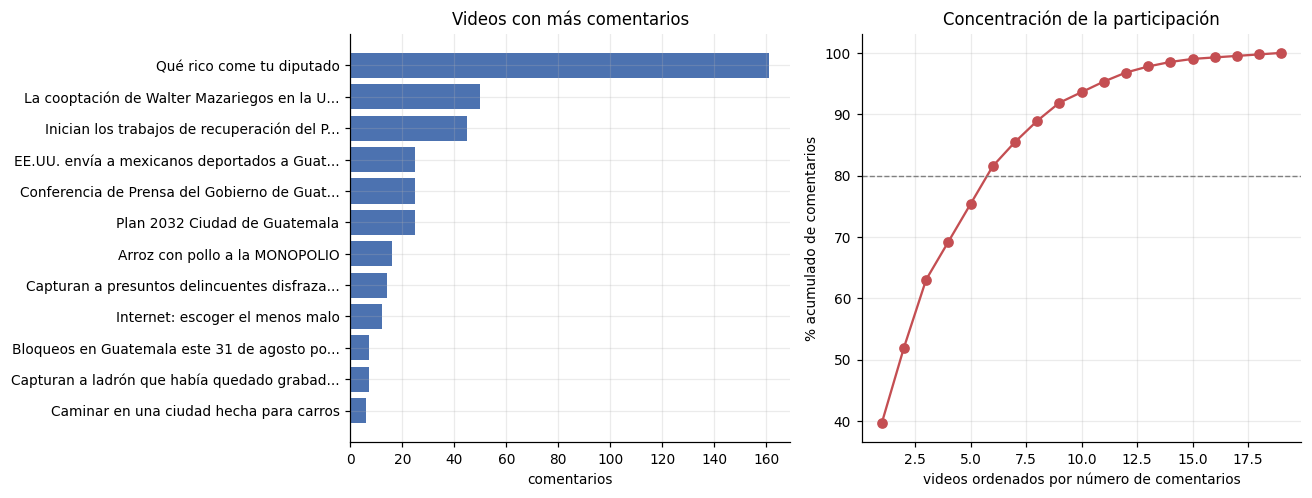

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

top = por_video.sort_values('comentarios').tail(12)
etiquetas = [t[:42] + ('...' if len(t) > 42 else '') for t in top.title]
ax[0].barh(etiquetas, top.comentarios, color='#4C72B0')
ax[0].set_xlabel('comentarios')
ax[0].set_title('Videos con más comentarios')

acum = 100 * serie_video.cumsum() / serie_video.sum()
ax[1].plot(range(1, len(acum) + 1), acum.values, marker='o', color='#C44E52')
ax[1].axhline(80, ls='--', lw=0.9, color='gray')
ax[1].set_xlabel('videos ordenados por número de comentarios')
ax[1].set_ylabel('% acumulado de comentarios')
ax[1].set_title('Concentración de la participación')
plt.tight_layout()
plt.show()

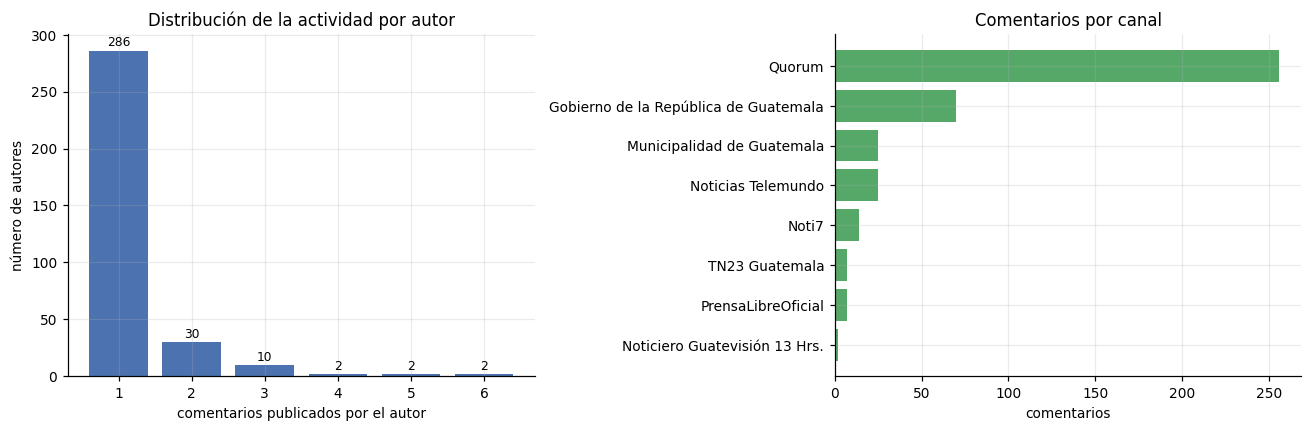

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

dist_autor = por_autor.comentarios.value_counts().sort_index()
ax[0].bar(dist_autor.index.astype(str), dist_autor.values, color='#4C72B0')
for x, y in zip(range(len(dist_autor)), dist_autor.values):
    ax[0].text(x, y + 4, str(y), ha='center', fontsize=8)
ax[0].set_xlabel('comentarios publicados por el autor')
ax[0].set_ylabel('número de autores')
ax[0].set_title('Distribución de la actividad por autor')

canal_top = por_canal_com.sort_values('comentarios')
ax[1].barh(canal_top.channel_name, canal_top.comentarios, color='#55A868')
ax[1].set_xlabel('comentarios')
ax[1].set_title('Comentarios por canal')
plt.tight_layout()
plt.show()

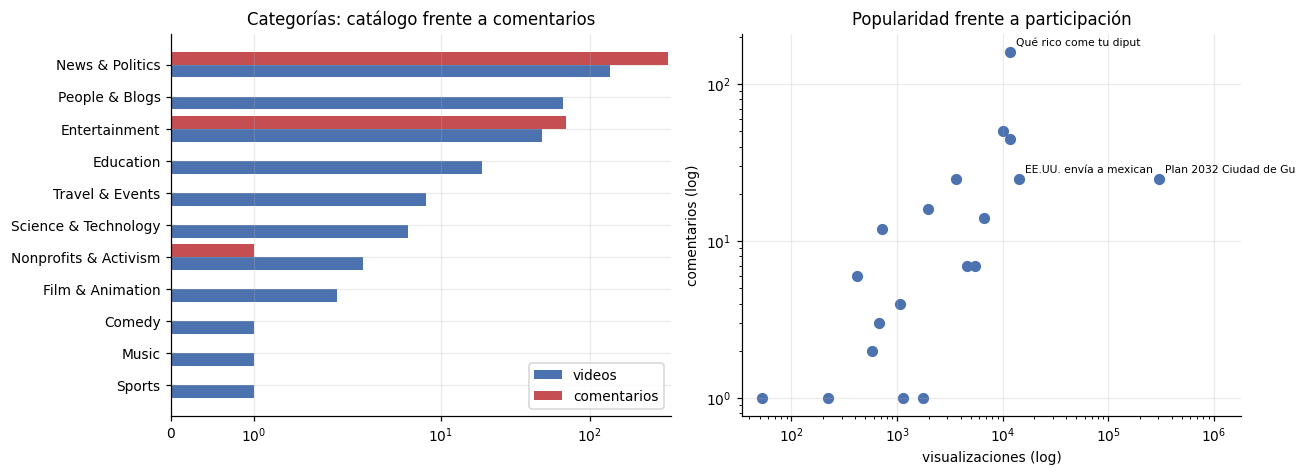

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

cat_plot = cat.sort_values('videos', ascending=True)
y = np.arange(len(cat_plot))
ax[0].barh(y - 0.2, cat_plot.videos, height=0.4, label='videos', color='#4C72B0')
ax[0].barh(y + 0.2, cat_plot.comentarios, height=0.4, label='comentarios', color='#C44E52')
ax[0].set_yticks(y, cat_plot.index)
ax[0].set_xscale('symlog')
ax[0].legend()
ax[0].set_title('Categorías: catálogo frente a comentarios')

ax[1].scatter(por_video.view_count, por_video.comentarios, s=40, color='#4C72B0')
for vid, fila in por_video.nlargest(3, 'view_count').iterrows():
    ax[1].annotate(fila.title[:22], (fila.view_count, fila.comentarios), fontsize=7,
                   xytext=(4, 4), textcoords='offset points')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim(right=por_video.view_count.max() * 6)
ax[1].set_xlabel('visualizaciones (log)')
ax[1].set_ylabel('comentarios (log)')
ax[1].set_title('Popularidad frente a participación')
plt.tight_layout()
plt.show()

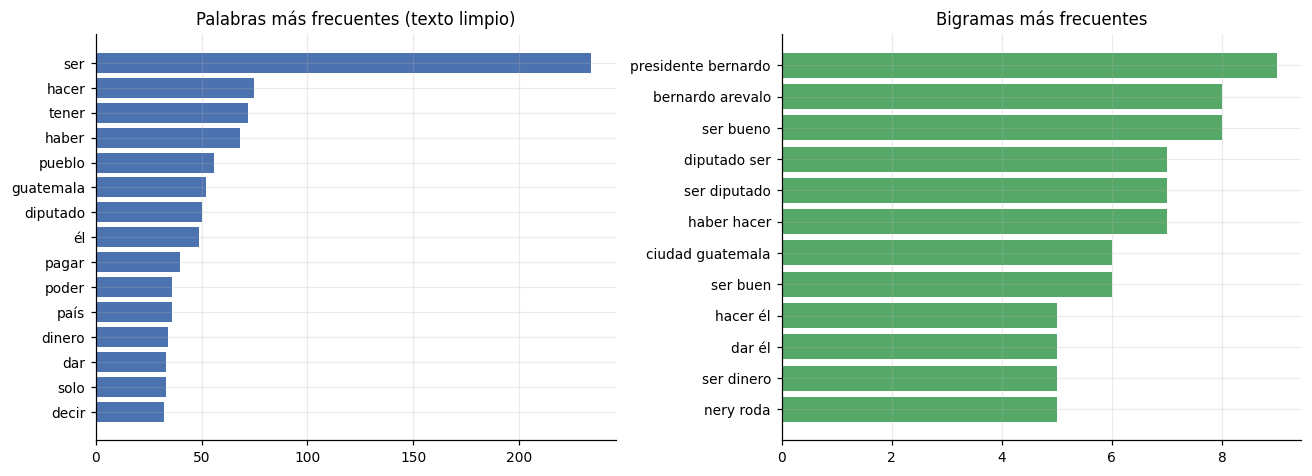

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

pal = pd.Series(dict(Counter(tokens).most_common(15))).sort_values()
ax[0].barh(pal.index, pal.values, color='#4C72B0')
ax[0].set_title('Palabras más frecuentes (texto limpio)')

big = pd.Series(dict(Counter(bigramas).most_common(12))).sort_values()
ax[1].barh(big.index, big.values, color='#55A868')
ax[1].set_title('Bigramas más frecuentes')
plt.tight_layout()
plt.show()

Los cuatro paneles refuerzan lo anterior. La curva de concentración cruza el 80 % de los comentarios en el sexto video de diecinueve. La distribución de actividad por autor decae de forma abrupta desde 286 autores con un comentario hasta dos autores con seis. La comparación por categoría muestra que People & Blogs, Education y Travel & Events tienen videos pero ninguna participación recolectada. El diagrama de dispersión en escala logarítmica muestra la asociación positiva y deja a "Plan 2032" claramente por debajo de la tendencia.

#### **3.5** Preguntas obligatorias

In [39]:
puentes = por_autor[por_autor.videos > 1].join(catalogo_autores.set_index('author_channel_id')[['author_name']])
canales_por_autor = comentarios.groupby('author_channel_id').channel_name.apply(lambda s: sorted(set(s)))
puentes['canales'] = canales_por_autor
puentes['n_canales'] = puentes.canales.str.len()
puentes.sort_values(['videos', 'comentarios'], ascending=False)[
    ['author_name', 'comentarios', 'videos', 'n_canales', 'canales']]

,author_name,comentarios,videos,n_canales,canales
author_channel_id,,,,,
UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3,1,[Quorum]
UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,1,[Quorum]
UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,3,2,2,"[Gobierno de la República de Guatemala, Quorum]"
UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,3,2,1,[Quorum]
UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2,1,[Quorum]
UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,2,"[Quorum, TN23 Guatemala]"
UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2,"[Gobierno de la República de Guatemala, Noti7]"
UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2,"[PrensaLibreOficial, Quorum]"
UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,1,[Gobierno de la República de Guatemala]


In [40]:
pares = (comentarios[['author_channel_id', 'video_id']].drop_duplicates()
         .merge(comentarios[['author_channel_id', 'video_id']].drop_duplicates(), on='author_channel_id'))
pares = pares[pares.video_id_x < pares.video_id_y]
solapamiento = (pares.groupby(['video_id_x', 'video_id_y']).size()
                .rename('autores_compartidos').reset_index()
                .sort_values('autores_compartidos', ascending=False))
solapamiento['video_x'] = solapamiento.video_id_x.map(videos.set_index('video_id').title).str[:38]
solapamiento['video_y'] = solapamiento.video_id_y.map(videos.set_index('video_id').title).str[:38]
solapamiento[['video_x', 'video_y', 'autores_compartidos']]

,video_x,video_y,autores_compartidos
10,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
7,La cooptación de Walter Mazariegos en,Qué rico come tu diputado,2
0,Capturan a presuntos delincuentes disf,Inician los trabajos de recuperación d,1
2,Conferencia de Prensa del Gobierno de,Qué rico come tu diputado,1
1,Inician los trabajos de recuperación d,Conferencia de Prensa del Gobierno de,1
3,Caminar en una ciudad hecha para carro,Internet: escoger el menos malo,1
4,Caminar en una ciudad hecha para carro,Arroz con pollo a la MONOPOLIO,1
6,Capturan a ladrón que había quedado gr,La cooptación de Walter Mazariegos en,1
5,Bloqueos en Guatemala este 31 de agost,Qué rico come tu diputado,1
8,La cooptación de Walter Mazariegos en,Internet: escoger el menos malo,1


In [41]:
POSITIVAS = set('''bueno buena buenos buenas excelente bello bella hermoso hermosa lindo linda felicidades
gracias bendiga bendicion apoyo exito exitos genial increible orgullo orgulloso admirable maravilloso viva
esperanza mejor mejorar bendiciones aplausos gran grande interesante util correcto cierto adelante progreso
amor paz feliz alegria bienvenido saludos'''.split())
NEGATIVAS = set('''corrupto corrupta corruptos corrupcion ladron ladrones robar roban robo sinverguenza
mentira mentiras mentiroso pesimo malo mala malos malas peor horrible vergonzoso verguenza basura asco
fraude impunidad pobreza miseria fracaso ineptos inepto inutil abuso injusticia desastre triste lastima
nunca danio hambre miedo violencia narco vendido traidor'''.split())

def polaridad(texto):
    palabras = re.findall(r'[a-z]+', unicodedata.normalize('NFKD', texto.lower())
                          .encode('ascii', 'ignore').decode())
    pos = sum(p in POSITIVAS for p in palabras)
    neg = sum(p in NEGATIVAS for p in palabras)
    return 'positivo' if pos > neg else ('negativo' if neg > pos else 'neutral')

comentarios['polaridad'] = comentarios.texto_original.apply(polaridad)
print(comentarios.polaridad.value_counts(normalize=True).round(3).to_string())

tabla_pol = pd.crosstab(comentarios.video_id, comentarios.polaridad, normalize='index').round(2)
tabla_pol['n'] = comentarios.video_id.value_counts()
tabla_pol['titulo'] = tabla_pol.index.map(videos.set_index('video_id').title).str[:44]
tabla_pol[tabla_pol.n >= 12].sort_values('n', ascending=False)

polaridad
neutral     0.616
positivo    0.229
negativo    0.155


polaridad,negativo,neutral,positivo,n,titulo
video_id,,,,,
n8iP75gIpmw,0.24,0.65,0.11,161,Qué rico come tu diputado
j43HgwYFKfk,0.20,0.64,0.16,50,La cooptación de Walter Mazariegos en la USA
6W4u8sGEnGM,0.16,0.49,0.36,45,Inician los trabajos de recuperación del Pue
PjmxCj-a9Hg,0.04,0.68,0.28,25,Conferencia de Prensa del Gobierno de Guatem
OkXlHx0hx-8,0.08,0.72,0.20,25,EE.UU. envía a mexicanos deportados a Guatem
lj983NWyAQY,0.00,0.36,0.64,25,Plan 2032 Ciudad de Guatemala
yLZS3JiEBg8,0.06,0.56,0.38,16,Arroz con pollo a la MONOPOLIO
06mFNPU0aB8,0.00,0.86,0.14,14,Capturan a presuntos delincuentes disfrazado
ndAZjHqzzT8,0.08,0.42,0.50,12,Internet: escoger el menos malo


¿Qué videos y canales concentran la mayor participación? "Qué rico come tu diputado" con 161 comentarios (39.7 % del total) y, a nivel de canal, Quorum con 256 comentarios (63.1 %) repartidos en 11 videos. Los siguientes son Gobierno de la República de Guatemala con 70 comentarios y luego un grupo de medios con 25 o menos.

¿Existen audiencias compartidas? Sí, pero muy poco. Solo 9 de 332 autores comentaron en más de un video, y el solapamiento entre videos alcanza como máximo 2 autores compartidos, entre "Qué rico come tu diputado" y "La cooptación de Walter Mazariegos en la USAC", ambos de Quorum. Solo 11 de los 171 pares posibles de videos comparten al menos un autor.

¿Qué autores funcionan como puentes? Los nueve autores multivideo, y en particular los cuatro que cruzan canales distintos: uno conecta Quorum con Gobierno de la República, otro Quorum con TN23, otro Quorum con PrensaLibre y otro Gobierno de la República con Noti7. Sin ellos, cada canal quedaría como un grupo separado. Los dos autores con más videos son `@inge_vergueta` y `@hashojea7348`, ambos con 3 videos y solo dentro de Quorum.

¿Qué temas y sentimientos caracterizan a los grupos de participación? Como todavía no se ejecuta la detección formal de comunidades, se usan los videos como agrupamiento provisional y una polaridad por léxico como aproximación. El resultado divide el corpus en dos bloques claros. El bloque crítico corresponde a Quorum, con vocabulario de diputado, pueblo, sueldo, dinero y pacto corrupto, y la mayor proporción de comentarios negativos: 24 % en "Qué rico come tu diputado" y 20 % en el video de la USAC. El bloque institucional corresponde a Municipalidad y Gobierno, con vocabulario de proyecto, ciudad, presidente y saludos, y polaridad mayoritariamente positiva: 64 % de positivos y ningún negativo en "Plan 2032". Este resultado es preliminar; el análisis formal de sentimiento corresponde a la sección 9.

¿La visibilidad coincide con la participación? Solo en parte. La correlación de rangos entre vistas y comentarios es alta (0.811), pero la tasa de comentarios por mil vistas varía en dos órdenes de magnitud y el video más visto del subconjunto es el que menos comenta en términos relativos. Además, la mediana de vistas de los videos comentados es apenas mayor que la de los no comentados, así que la visibilidad no explica qué videos entraron a la muestra.

¿Qué conclusiones quedan limitadas por el procedimiento de recolección? Prácticamente todas las que involucren el catálogo completo. El 93.5 % de los videos no tiene comentarios recolectados, los 105 videos del grupo `official_gov` tienen cero, y una sola consulta aporta más de la mitad de los comentarios. Cualquier afirmación sobre qué temas generan más conversación en YouTube Guatemala estaría midiendo la estrategia de scraping y no el comportamiento de los usuarios.

#### **3.6** Preguntas adicionales

In [42]:
lk = por_video[['title', 'comentarios', 'likes']].copy()
lk['pct_comentarios'] = (100 * lk.comentarios / lk.comentarios.sum()).round(1)
lk['pct_likes'] = (100 * lk.likes / lk.likes.sum()).round(1)
print('Spearman comentarios-me gusta por video:',
      round(spearmanr(lk.comentarios, lk.likes)[0], 3))
lk.sort_values('likes', ascending=False).head(6)

Spearman comentarios-me gusta por video: 0.871


,title,comentarios,likes,pct_comentarios,pct_likes
video_id,,,,,
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,1697,6.2,73.0
n8iP75gIpmw,Qué rico come tu diputado,161,358,39.7,15.4
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,91,12.3,3.9
6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,90,11.1,3.9
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,25,25,6.2,1.1
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,20,6.2,0.9


In [43]:
cobertura = videos.assign(n_com=videos.video_id.map(comentarios.video_id.value_counts()).fillna(0))
cobertura.groupby('source_group').agg(
    videos=('video_id', 'size'),
    videos_con_comentarios=('n_com', lambda s: int((s > 0).sum())),
    comentarios=('n_com', 'sum'),
    vistas_mediana=('view_count', 'median')).astype(int)

,videos,videos_con_comentarios,comentarios,vistas_mediana
source_group,,,,
channel,11,7,43,673
official_gov,105,0,0,521
topic,177,12,363,2214


In [44]:
comentarios['n_palabras'] = comentarios.texto_original.str.split().str.len()
comentarios.groupby('channel_name').n_palabras.agg(['count', 'mean', 'median']).round(1) \
    .sort_values('count', ascending=False)

,count,mean,median
channel_name,,,
Quorum,256,26.4,18.0
Gobierno de la República de Guatemala,70,25.7,21.0
Noticias Telemundo,25,16.2,15.0
Municipalidad de Guatemala,25,17.0,12.0
Noti7,14,9.6,6.5
PrensaLibreOficial,7,24.1,17.0
TN23 Guatemala,7,7.0,7.0
Noticiero Guatevisión 13 Hrs.,2,12.0,12.0


Primera pregunta: ¿los videos con más comentarios son también los que reciben más "me gusta"? No necesariamente. La correlación de rangos es alta (0.871), pero "Plan 2032 Ciudad de Guatemala" concentra el 73 % de todos los "me gusta" con apenas el 6.2 % de los comentarios, mientras que el video más comentado reúne el 39.7 % de los comentarios y solo el 15.4 % de los "me gusta". Comentar y reaccionar son formas de participación distintas: la primera exige redactar y la segunda no, y en este corpus se activan en videos diferentes.

Segunda pregunta: ¿la cobertura de comentarios depende de la estrategia de recolección? De forma determinante. Los 105 videos del grupo `official_gov` no tienen ni un solo comentario recolectado, pese a tener una mediana de vistas comparable a la del resto. El grupo `topic` aporta 363 comentarios repartidos en 12 videos y el grupo `channel` aporta 43 en 7 videos. La ausencia de comentarios en más del 90 % del catálogo es un artefacto del diseño de recolección y no evidencia de que esos videos no tengan conversación.

Tercera pregunta: ¿la extensión del comentario varía según el canal? Sí, y el patrón acompaña al tipo de contenido. Los comentarios en Quorum promedian 26.4 palabras y los de Gobierno de la República 25.7, mientras que los de Noti7 promedian 9.6 y los de TN23 solo 7.0. Los videos de análisis político generan intervenciones más largas y argumentadas; las notas de nota roja generan reacciones breves. La diferencia debe leerse con cuidado porque los canales con menos comentarios tienen muestras de 7 a 14 casos.

### **4.** Construcción de la red bipartita autor-video

#### **4.1 y 4.2** Construcción de la red y definición de aristas y pesos

Se construye un grafo no dirigido con dos conjuntos disjuntos de nodos: los 332 autores identificados por `author_channel_id` y los 19 videos comentados identificados por `video_id`. Se crea una arista entre un autor y un video cuando ese autor publicó al menos un comentario en ese video, y el peso es el número de comentarios que ese autor publicó en ese video. Las 36 filas que son respuestas se cuentan como participación normal del autor en el video, ya que la arista describe presencia y no jerarquía conversacional.

In [45]:
aristas = (comentarios.groupby(['author_channel_id', 'video_id'])
           .agg(peso=('comment_id', 'size'),
                likes=('like_count', 'sum'),
                respuestas=('reply_count', 'sum'))
           .reset_index())

G = nx.Graph()
G.add_nodes_from(comentarios.author_channel_id.unique(), tipo='autor', bipartite=0)
G.add_nodes_from(comentarios.video_id.unique(), tipo='video', bipartite=1)
for fila in aristas.itertuples(index=False):
    G.add_edge(fila.author_channel_id, fila.video_id, weight=fila.peso,
               likes=int(fila.likes), respuestas=int(fila.respuestas))

AUTORES = {n for n, d in G.nodes(data=True) if d['tipo'] == 'autor'}
VIDEOS = {n for n, d in G.nodes(data=True) if d['tipo'] == 'video'}

print('nodos:', G.number_of_nodes(), '| autores:', len(AUTORES), '| videos:', len(VIDEOS))
print('aristas:', G.number_of_edges())
print('es bipartita:', bipartite.is_bipartite(G))
print('suma de pesos:', int(sum(d['weight'] for _, _, d in G.edges(data=True))),
      '| comentarios totales:', len(comentarios))
print('\ndistribución de pesos:')
print(aristas.peso.value_counts().sort_index().to_string())

nodos: 351 | autores: 332 | videos: 19
aristas: 343
es bipartita: True
suma de pesos: 406 | comentarios totales: 406

distribución de pesos:
peso
1    303
2     28
3      7
4      1
5      2
6      2


#### **4.3** Tabla de nodos y tabla de aristas

In [46]:
nodos_autor = (comentarios.groupby('author_channel_id')
               .agg(comentarios=('comment_id', 'size'),
                    videos=('video_id', 'nunique'),
                    canales=('channel_id', 'nunique'),
                    likes=('like_count', 'sum'),
                    respuestas=('reply_count', 'sum'))
               .join(catalogo_autores.set_index('author_channel_id')[['author_name', 'author_handle']])
               .reset_index().rename(columns={'author_channel_id': 'id', 'author_name': 'etiqueta'}))
nodos_autor['tipo'] = 'autor'

nodos_video = (por_video.reset_index()
               .rename(columns={'video_id': 'id', 'title': 'etiqueta'})
               [['id', 'etiqueta', 'comentarios', 'autores', 'likes', 'respuestas',
                 'channel_name', 'view_count', 'category']])
nodos_video['tipo'] = 'video'

tabla_nodos = pd.concat([nodos_autor, nodos_video], ignore_index=True)
tabla_nodos['grado'] = tabla_nodos.id.map(dict(G.degree()))
tabla_nodos['grado_ponderado'] = tabla_nodos.id.map(dict(G.degree(weight='weight')))
tabla_nodos = tabla_nodos[['id', 'etiqueta', 'tipo', 'grado', 'grado_ponderado', 'comentarios',
                           'autores', 'videos', 'canales', 'likes', 'respuestas',
                           'author_handle', 'channel_name', 'view_count', 'category']]

tabla_aristas = aristas.rename(columns={'author_channel_id': 'origen', 'video_id': 'destino'})
tabla_aristas['tipo_arista'] = 'autor-video'

tabla_nodos.to_csv(f'{RUTA}/nodos_bipartita.csv', index=False)
tabla_aristas.to_csv(f'{RUTA}/aristas_bipartita.csv', index=False)

print('tabla de nodos:', tabla_nodos.shape, '| tabla de aristas:', tabla_aristas.shape)
tabla_nodos[tabla_nodos.tipo == 'video'].sort_values('grado', ascending=False).head(6)[
    ['id', 'etiqueta', 'tipo', 'grado', 'grado_ponderado', 'autores', 'likes', 'channel_name', 'view_count']]

tabla de nodos: (351, 15) | tabla de aristas: (343, 6)


,id,etiqueta,tipo,grado,grado_ponderado,autores,likes,channel_name,view_count
346,n8iP75gIpmw,Qué rico come tu diputado,video,128,161,128.0,358,Quorum,11775.0
344,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,video,49,50,49.0,91,Quorum,10156.0
334,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,video,32,45,32.0,90,Gobierno de la República de Guatemala,11670.0
345,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,video,25,25,25.0,1697,Municipalidad de Guatemala,304089.0
337,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,video,19,25,19.0,20,Gobierno de la República de Guatemala,3628.0
336,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,video,18,25,18.0,25,Noticias Telemundo,14200.0


In [47]:
tabla_nodos[tabla_nodos.tipo == 'autor'].sort_values(
    ['grado', 'grado_ponderado'], ascending=False).head(8)[
    ['id', 'etiqueta', 'tipo', 'grado', 'grado_ponderado', 'comentarios', 'videos', 'canales', 'likes']]

,id,etiqueta,tipo,grado,grado_ponderado,comentarios,videos,canales,likes
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,autor,3,4,4,3.0,1.0,0
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,autor,3,3,3,3.0,1.0,4
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,autor,2,3,3,2.0,2.0,14
325,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,autor,2,3,3,2.0,1.0,1
207,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,autor,2,2,2,2.0,1.0,0
211,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,autor,2,2,2,2.0,2.0,0
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,autor,2,2,2,2.0,2.0,0
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,autor,2,2,2,2.0,2.0,0


In [48]:
tabla_aristas.sort_values('peso', ascending=False).head(8)

,origen,destino,peso,likes,respuestas,tipo_arista
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6,1,0,autor-video
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6,14,0,autor-video
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5,6,0,autor-video
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5,17,0,autor-video
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4,0,0,autor-video
120,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,3,3,1,autor-video
85,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,3,3,0,autor-video
234,UCh5ESQvtzyHDhCA7XyekCFA,n8iP75gIpmw,3,4,0,autor-video


#### **4.4** Visualización de la red completa

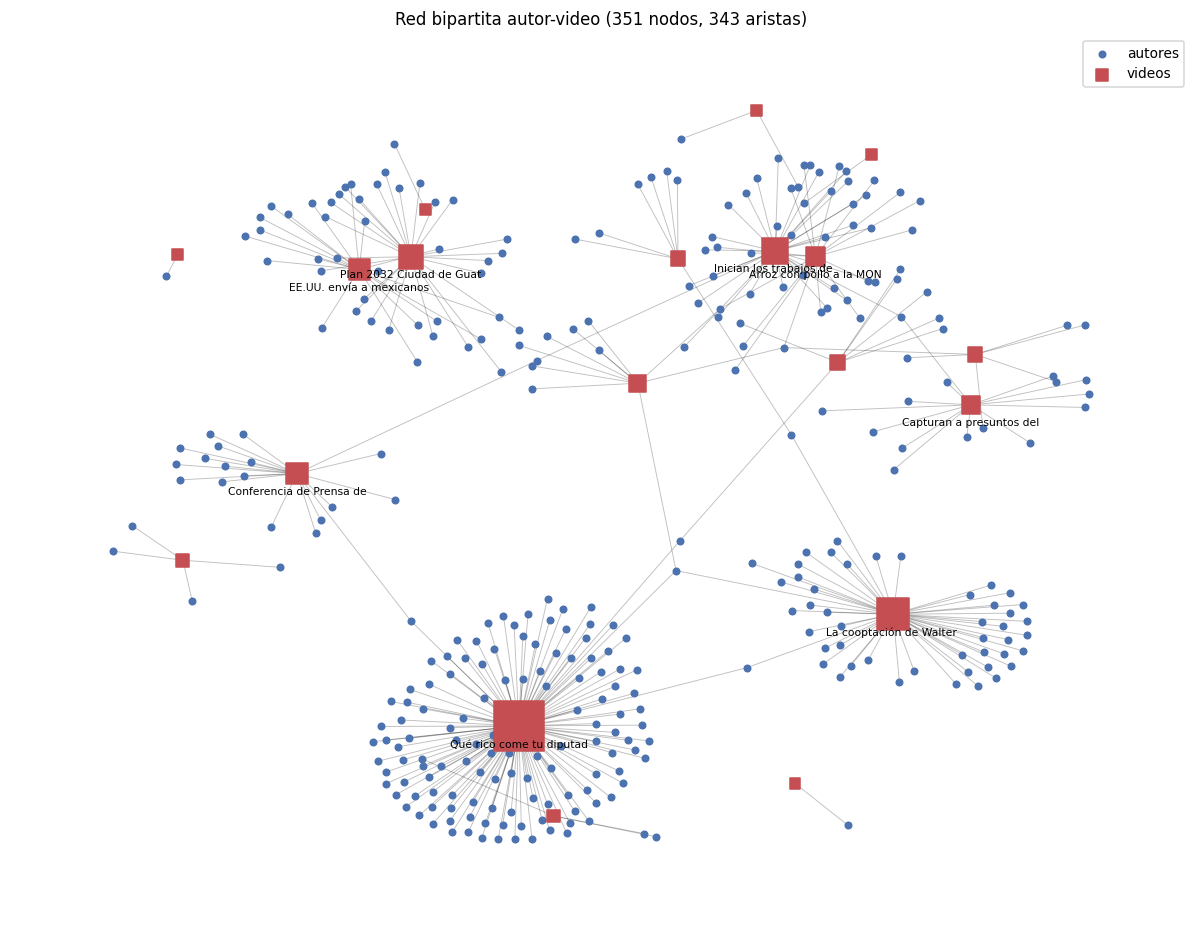

In [49]:
pos = nx.spring_layout(G, k=0.35, seed=7, iterations=120)
fig, ax = plt.subplots(figsize=(11, 8.5))

nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=sorted(AUTORES), node_size=18,
                       node_color='#4C72B0', ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=sorted(VIDEOS),
                       node_size=[40 + 8 * G.degree(n) for n in sorted(VIDEOS)],
                       node_color='#C44E52', node_shape='s', ax=ax)
etiquetas_video = {n: videos.set_index('video_id').title[n][:24] for n in VIDEOS if G.degree(n) >= 13}
pos_texto = {n: (x, y - 0.045) for n, (x, y) in pos.items()}
nx.draw_networkx_labels(G, pos_texto, labels=etiquetas_video, font_size=7, ax=ax)

ax.scatter([], [], s=18, c='#4C72B0', label='autores')
ax.scatter([], [], s=60, c='#C44E52', marker='s', label='videos')
ax.legend(loc='upper right')
ax.set_title('Red bipartita autor-video (351 nodos, 343 aristas)')
ax.grid(False)
ax.axis('off')
plt.tight_layout()
plt.show()

densidad bipartita: 0.0544
grado medio de autores: 1.033 (máximo 3)
grado medio de videos: 18.05 (máximo 128)
componentes conexas: 10 | tamaños: [286, 26, 19, 5, 4, 3, 2, 2, 2, 2]
componente mayor: 286 nodos (81.5%)


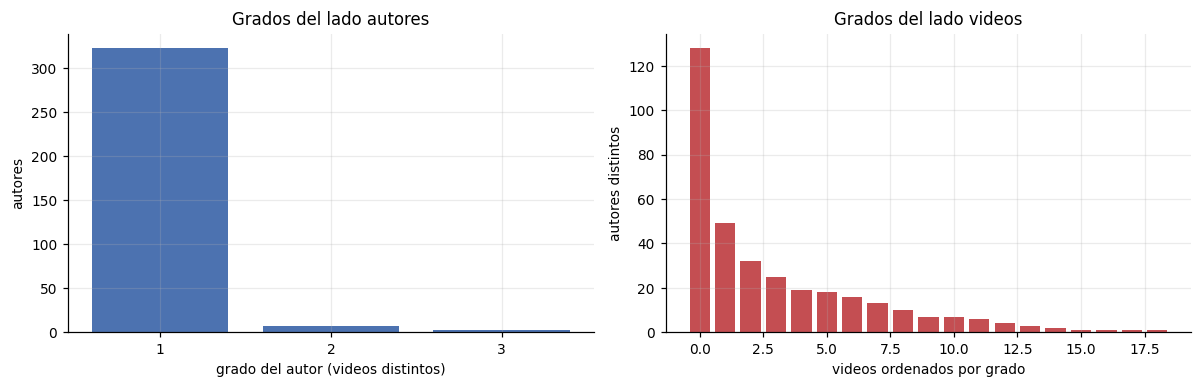

In [50]:
grados_autor = [G.degree(n) for n in AUTORES]
grados_video = [G.degree(n) for n in VIDEOS]
componentes = sorted((len(c) for c in nx.connected_components(G)), reverse=True)

print(f'densidad bipartita: {bipartite.density(G, AUTORES):.4f}')
print(f'grado medio de autores: {np.mean(grados_autor):.3f} (máximo {max(grados_autor)})')
print(f'grado medio de videos: {np.mean(grados_video):.2f} (máximo {max(grados_video)})')
print(f'componentes conexas: {len(componentes)} | tamaños: {componentes}')
print(f'componente mayor: {componentes[0]} nodos ({componentes[0] / G.number_of_nodes():.1%})')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
d_aut = pd.Series(grados_autor).value_counts().sort_index()
ax[0].bar(d_aut.index.astype(str), d_aut.values, color='#4C72B0')
ax[0].set_xlabel('grado del autor (videos distintos)')
ax[0].set_ylabel('autores')
ax[0].set_title('Grados del lado autores')
ax[1].bar(range(len(grados_video)), sorted(grados_video, reverse=True), color='#C44E52')
ax[1].set_xlabel('videos ordenados por grado')
ax[1].set_ylabel('autores distintos')
ax[1].set_title('Grados del lado videos')
plt.tight_layout()
plt.show()

La red tiene 351 nodos y 343 aristas, con densidad bipartita de 0.054. La asimetría entre los dos lados es la característica dominante: el grado medio de los autores es 1.03 y el de los videos 18.05. En términos concretos, 323 de 332 autores están unidos a un solo video y ningún autor supera los 3 videos, mientras que el video central concentra 128 autores distintos.

El resultado visual es un conjunto de estrellas: cada video es un centro rodeado de autores que solo aparecen ahí. La red se separa en 10 componentes conexas. La mayor tiene 286 nodos, el 81.5 % del total, y agrupa 10 videos unidos exclusivamente por los pocos autores que comentaron en más de uno. Las otras nueve componentes son videos aislados con su propio público, entre ellos "Plan 2032" con sus 25 autores y "EE.UU. envía a mexicanos deportados" con 18.

**La cohesión de la componente mayor depende de un número muy pequeño de autores puente, de modo que eliminar a menos de diez personas fragmentaría la red en grupos separados por video.**

La suma de los pesos de las aristas es 406 y coincide con el número total de comentarios, lo que verifica que ningún comentario se perdió ni se contó dos veces. De las 343 aristas, 303 tienen peso 1 y solo 40 superan ese valor, con un máximo de 6.

#### **4.5** Qué significa una arista

Una arista entre un autor y un video significa una sola cosa: ese autor publicó al menos un comentario en ese video, y el peso indica cuántos. Nada más.

En particular, una arista no implica que el autor haya visto el video completo, ni que apruebe su contenido, ya que buena parte de los comentarios son críticos hacia el video o hacia sus protagonistas. Dos autores conectados al mismo video no son amigos, no se conocen y no necesariamente se leyeron entre sí: comparten un espacio de publicación, no una conversación. Los datos tampoco permiten reconstruir quién respondió a quién de forma completa, así que la coparticipación es lo máximo que se puede afirmar.

Tampoco es correcto leer la ausencia de arista como desinterés. Un autor sin conexión a un video puede haberlo comentado sin que el comentario entrara en la recolección, y 274 videos del catálogo no tienen ninguna arista simplemente porque no se recolectaron sus comentarios. La red describe participación observada, no participación real.

### **5.** Proyecciones de la red

#### **5.1 y 5.2** Construcción de las proyecciones autor-autor y video-video

In [ ]:
P_autores = bipartite.weighted_projected_graph(G, AUTORES)
P_videos = bipartite.weighted_projected_graph(G, VIDEOS)

print(f'Proyección autor-autor: {P_autores.number_of_nodes()} nodos, {P_autores.number_of_edges()} aristas')
print(f'Proyección video-video: {P_videos.number_of_nodes()} nodos, {P_videos.number_of_edges()} aristas')
print()
print('distribución de pesos autor-autor:',
      dict(sorted(Counter(d['weight'] for _, _, d in P_autores.edges(data=True)).items())))
print('distribución de pesos video-video:',
      dict(sorted(Counter(d['weight'] for _, _, d in P_videos.edges(data=True)).items())))


Proyección autor-autor: 332 nodos, 10732 aristas
Proyección video-video: 19 nodos, 11 aristas

distribución de pesos autor-autor: {1: 10730, 2: 2}
distribución de pesos video-video: {1: 9, 2: 2}


#### **5.3** Comparación de las proyecciones

In [52]:
comparacion_proy = pd.DataFrame({
    'autor-autor': {
        'nodos': P_autores.number_of_nodes(),
        'aristas': P_autores.number_of_edges(),
        'densidad': round(nx.density(P_autores), 4),
        'grado medio': round(np.mean([d for _, d in P_autores.degree()]), 2),
        'componentes': nx.number_connected_components(P_autores),
        'nodos aislados': sum(1 for n in P_autores if P_autores.degree(n) == 0),
    },
    'video-video': {
        'nodos': P_videos.number_of_nodes(),
        'aristas': P_videos.number_of_edges(),
        'densidad': round(nx.density(P_videos), 4),
        'grado medio': round(np.mean([d for _, d in P_videos.degree()]), 2),
        'componentes': nx.number_connected_components(P_videos),
        'nodos aislados': sum(1 for n in P_videos if P_videos.degree(n) == 0),
    },
})
comparacion_proy


,autor-autor,video-video
nodos,332.0000,19.0000
aristas,10732.0000,11.0000
densidad,0.1953,0.0643
grado medio,64.6500,1.1600
componentes,10.0000,10.0000
nodos aislados,4.0000,9.0000


#### **5.4** Visualización de las proyecciones

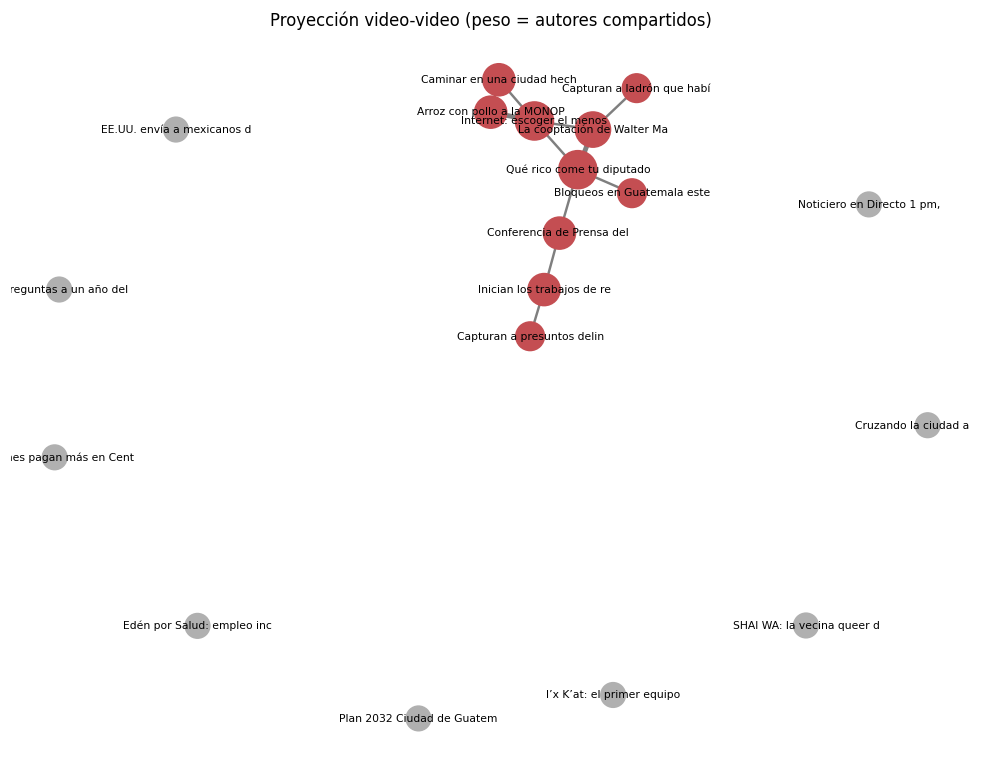

In [53]:
# Video-video: solo 19 nodos, se puede etiquetar y pesar el grosor de las aristas
# según el número de autores compartidos.
fig, ax = plt.subplots(figsize=(9, 7))
pos_v = nx.spring_layout(P_videos, k=0.9, seed=7, iterations=200)
pesos_v = [P_videos[u][v]['weight'] for u, v in P_videos.edges()]
grados_v = dict(P_videos.degree())

nx.draw_networkx_edges(P_videos, pos_v, width=[1.6 * w for w in pesos_v], alpha=0.5, ax=ax)
nx.draw_networkx_nodes(P_videos, pos_v,
                        node_size=[260 + 90 * grados_v[n] for n in P_videos.nodes()],
                        node_color=['#C44E52' if grados_v[n] > 0 else '#B0B0B0' for n in P_videos.nodes()],
                        ax=ax)
etiquetas_v = {n: videos.set_index('video_id').title[n][:26] for n in P_videos.nodes()}
nx.draw_networkx_labels(P_videos, pos_v, labels=etiquetas_v, font_size=7, ax=ax)
ax.set_title('Proyección video-video (peso = autores compartidos)')
ax.axis('off')
plt.tight_layout()
plt.show()


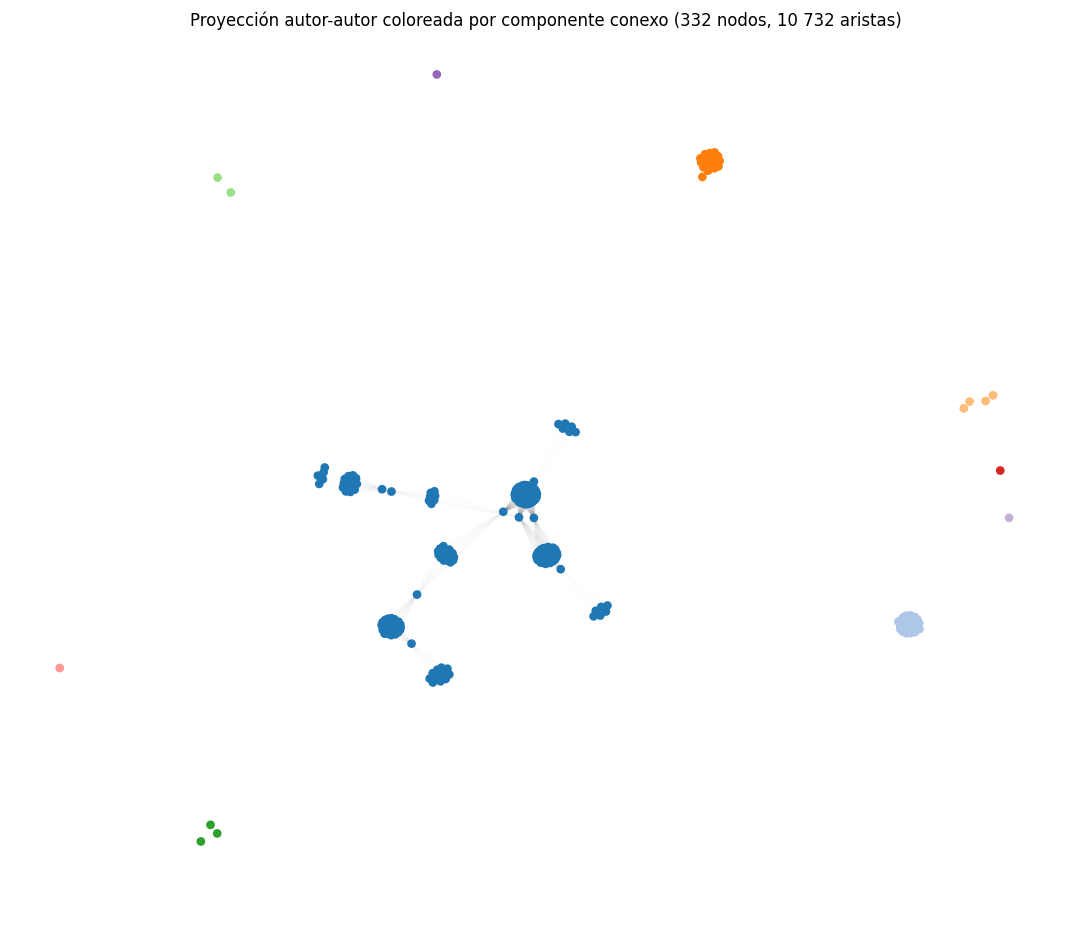

componentes en la proyección autor-autor: 10 | tamaños: [276, 25, 18, 4, 3, 2, 1, 1, 1, 1]


In [ ]:
componentes_aa = list(nx.connected_components(P_autores))
color_por_nodo = {}
paleta = plt.cm.tab20(np.linspace(0, 1, 20))
for i, comp in enumerate(sorted(componentes_aa, key=len, reverse=True)):
    for n in comp:
        color_por_nodo[n] = paleta[i % 20]

fig, ax = plt.subplots(figsize=(10, 8.5))
pos_a = nx.spring_layout(P_autores, k=0.12, seed=7, iterations=80)
nx.draw_networkx_edges(P_autores, pos_a, alpha=0.02, width=0.4, ax=ax)
nx.draw_networkx_nodes(P_autores, pos_a, node_size=22,
                        node_color=[color_por_nodo[n] for n in P_autores.nodes()], ax=ax)
ax.set_title('Proyección autor-autor coloreada por componente conexo (332 nodos, 10 732 aristas)')
ax.axis('off')
plt.tight_layout()
plt.show()
print('componentes en la proyección autor-autor:', len(componentes_aa),
      '| tamaños:', sorted((len(c) for c in componentes_aa), reverse=True))


### **6.** Topología y fragmentación

#### **6.1** Nodos, aristas, densidad, grado y componentes

In [55]:
def resumen_topologico(red, nombre, nodos_izq=None):
    grados = [d for _, d in red.degree()]
    comps = sorted((len(c) for c in nx.connected_components(red)), reverse=True)
    fila = {
        'red': nombre,
        'nodos': red.number_of_nodes(),
        'aristas': red.number_of_edges(),
        'densidad': round(bipartite.density(red, nodos_izq) if nodos_izq else nx.density(red), 4),
        'grado medio': round(np.mean(grados), 2),
        'grado máximo': max(grados),
        'componentes': len(comps),
        'tamaño componente mayor': comps[0],
        '% en componente mayor': round(100 * comps[0] / red.number_of_nodes(), 1),
    }
    return fila

topologia = pd.DataFrame([
    resumen_topologico(G, 'bipartita autor-video', nodos_izq=AUTORES),
    resumen_topologico(P_autores, 'proyección autor-autor'),
    resumen_topologico(P_videos, 'proyección video-video'),
]).set_index('red')
topologia


,nodos,aristas,densidad,grado medio,grado máximo,componentes,tamaño componente mayor,% en componente mayor
red,,,,,,,,
bipartita autor-video,351,343,0.0544,1.95,128,10,286,81.5
proyección autor-autor,332,10732,0.1953,64.65,183,10,276,83.1
proyección video-video,19,11,0.0643,1.16,4,10,10,52.6


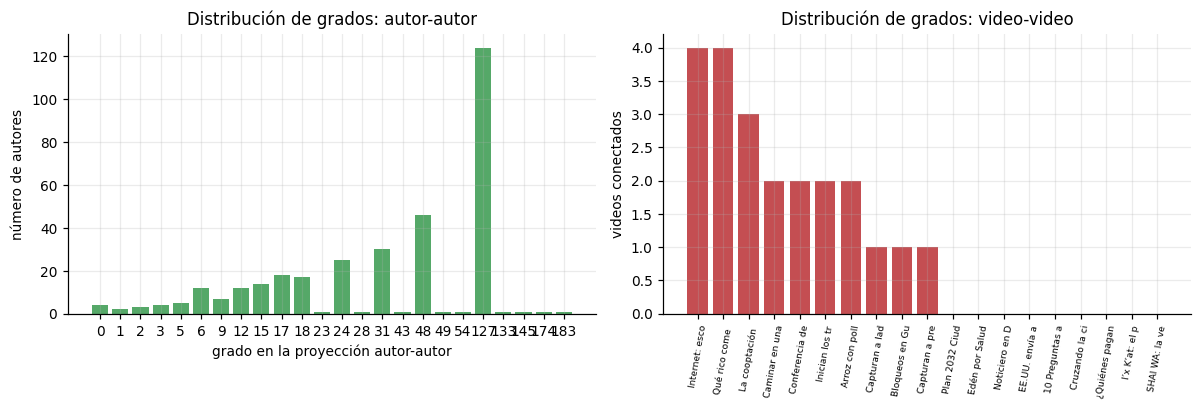

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
gr_aa = pd.Series([d for _, d in P_autores.degree()]).value_counts().sort_index()
ax[0].bar(gr_aa.index.astype(str), gr_aa.values, color='#55A868')
ax[0].set_xlabel('grado en la proyección autor-autor')
ax[0].set_ylabel('número de autores')
ax[0].set_title('Distribución de grados: autor-autor')

gr_vv = sorted([d for _, d in P_videos.degree()], reverse=True)
ax[1].bar(range(len(gr_vv)), gr_vv, color='#C44E52')
ax[1].set_xticks(range(len(gr_vv)))
ax[1].set_xticklabels([videos.set_index('video_id').title[n][:14] for n, _ in
                       sorted(P_videos.degree(), key=lambda x: -x[1])], rotation=80, fontsize=6)
ax[1].set_ylabel('videos conectados')
ax[1].set_title('Distribución de grados: video-video')
plt.tight_layout()
plt.show()


#### **6.2** Cohesión y transitividad

In [57]:
def cohesion(red, nombre):
    comps = sorted(nx.connected_components(red), key=len, reverse=True)
    gigante = red.subgraph(comps[0])
    fila = {
        'red': nombre,
        'transitividad global': round(nx.transitivity(red), 4),
        'clustering medio': round(nx.average_clustering(red), 4),
        'nodos en componente mayor': gigante.number_of_nodes(),
        'diámetro (comp. mayor)': nx.diameter(gigante) if gigante.number_of_nodes() > 1 else 0,
        'distancia media (comp. mayor)': round(nx.average_shortest_path_length(gigante), 3)
                                          if gigante.number_of_nodes() > 1 else 0,
    }
    return fila

cohesion_tabla = pd.DataFrame([
    cohesion(G, 'bipartita autor-video'),
    cohesion(P_autores, 'proyección autor-autor'),
    cohesion(P_videos, 'proyección video-video'),
]).set_index('red')
cohesion_tabla


,transitividad global,clustering medio,nodos en componente mayor,diámetro (comp. mayor),distancia media (comp. mayor)
red,,,,,
bipartita autor-video,0.0000,0.0000,286,12,4.715
proyección autor-autor,0.9840,0.9720,276,6,2.356
proyección video-video,0.3158,0.1491,10,5,2.489


#### **6.3** Nodos, videos y grupos periféricos o aislados

In [58]:
print('=== Aislamiento observado (dentro de la red construida) ===')
print(f'autores con grado 1 en la bipartita (comentaron un único video): '
      f'{sum(1 for n in AUTORES if G.degree(n) == 1)} de {len(AUTORES)} '
      f'({sum(1 for n in AUTORES if G.degree(n) == 1) / len(AUTORES):.1%})')
print(f'autores sin ningún coautor de video (aislados en la proyección autor-autor): '
      f'{sum(1 for n in P_autores if P_autores.degree(n) == 0)}')
print(f'videos comentados sin ningún video con audiencia compartida (aislados en video-video): '
      f'{sum(1 for n in P_videos if P_videos.degree(n) == 0)} de {len(VIDEOS)}')

print()
print('=== Ausencia de datos (fuera de la red construida) ===')
print(f'videos del catálogo sin comentarios recolectados: {len(videos) - len(VIDEOS)} de {len(videos)} '
      f'({(len(videos) - len(VIDEOS)) / len(videos):.1%}) — no aparecen como nodos porque no hay datos, '
      f'no porque se haya observado que carecen de audiencia')


=== Aislamiento observado (dentro de la red construida) ===
autores con grado 1 en la bipartita (comentaron un único video): 323 de 332 (97.3%)
autores sin ningún coautor de video (aislados en la proyección autor-autor): 4
videos comentados sin ningún video con audiencia compartida (aislados en video-video): 9 de 19

=== Ausencia de datos (fuera de la red construida) ===
videos del catálogo sin comentarios recolectados: 274 de 293 (93.5%) — no aparecen como nodos porque no hay datos, no porque se haya observado que carecen de audiencia


### **7.** Comunidades

#### **7.2** Algoritmo aplicado

In [ ]:
from networkx.algorithms import community

comunidades = community.louvain_communities(G, weight='weight', seed=7, resolution=1.0)
modularidad = community.modularity(G, comunidades, weight='weight')

print(f'número de comunidades: {len(comunidades)}')
print(f'tamaños: {sorted((len(c) for c in comunidades), reverse=True)}')
print(f'modularidad: {modularidad:.4f}')


número de comunidades: 17
tamaños: [126, 48, 32, 31, 26, 19, 19, 14, 8, 8, 5, 4, 3, 2, 2, 2, 2]
modularidad: 0.7774


#### **7.4** Visualización de las comunidades

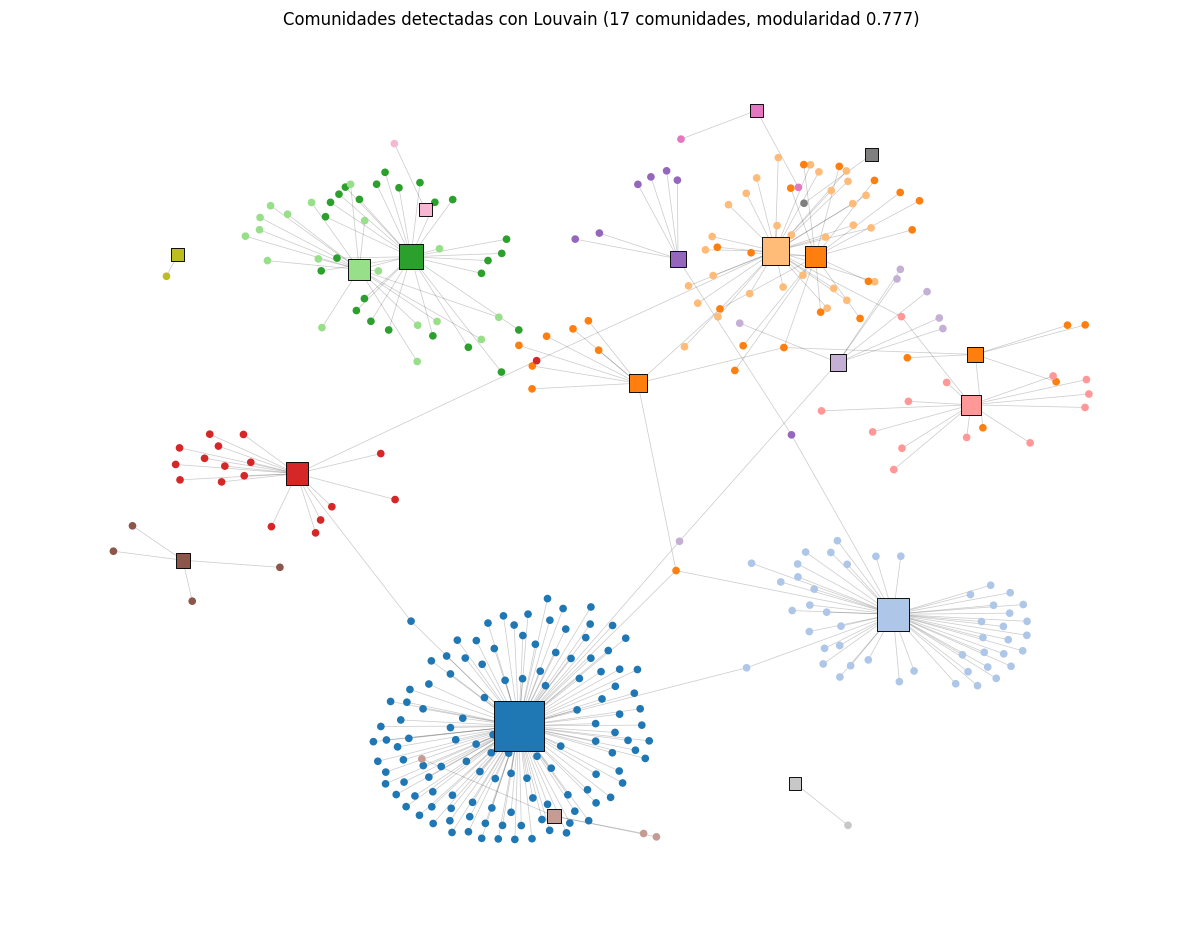

In [60]:
comunidades_ordenadas = sorted(comunidades, key=len, reverse=True)
color_comunidad = {}
paleta_com = plt.cm.tab20(np.linspace(0, 1, 20))
for i, com in enumerate(comunidades_ordenadas):
    for n in com:
        color_comunidad[n] = paleta_com[i % 20]

fig, ax = plt.subplots(figsize=(11, 8.5))
pos_c = nx.spring_layout(G, k=0.35, seed=7, iterations=120)
nx.draw_networkx_edges(G, pos_c, alpha=0.2, width=0.5, ax=ax)
nx.draw_networkx_nodes(G, pos_c, nodelist=sorted(AUTORES), node_size=16,
                       node_color=[color_comunidad[n] for n in sorted(AUTORES)], ax=ax)
nx.draw_networkx_nodes(G, pos_c, nodelist=sorted(VIDEOS),
                       node_size=[60 + 8 * G.degree(n) for n in sorted(VIDEOS)],
                       node_color=[color_comunidad[n] for n in sorted(VIDEOS)],
                       node_shape='s', edgecolors='black', linewidths=0.6, ax=ax)
ax.set_title(f'Comunidades detectadas con Louvain ({len(comunidades)} comunidades, modularidad {modularidad:.3f})')
ax.axis('off')
plt.tight_layout()
plt.show()


#### **7.5** Caracterización de las tres comunidades principales

In [61]:
def caracterizar_comunidad(com, etiqueta):
    vids_c = [n for n in com if n in VIDEOS]
    aut_c = [n for n in com if n in AUTORES]
    sub = comentarios[comentarios.video_id.isin(vids_c)]
    tokens = [t for s in sub.texto_limpio for t in s.split()]
    top_pal = [p for p, _ in Counter(tokens).most_common(6)]
    pol = sub.polaridad.value_counts(normalize=True).round(2).to_dict()
    return {
        'comunidad': etiqueta,
        'nodos': len(com),
        'autores': len(aut_c),
        'videos': len(vids_c),
        'canales': sorted(videos[videos.video_id.isin(vids_c)].channel_name.unique().tolist()),
        'comentarios': len(sub),
        'likes': int(sub.like_count.sum()),
        'temas frecuentes': top_pal,
        'sentimiento': pol,
    }

top3_comunidades = comunidades_ordenadas[:3]
caracterizacion = pd.DataFrame([
    caracterizar_comunidad(c, f'Comunidad {i + 1}') for i, c in enumerate(top3_comunidades)
]).set_index('comunidad')
caracterizacion


,nodos,autores,videos,canales,comentarios,likes,temas frecuentes,sentimiento
comunidad,,,,,,,,
Comunidad 1,126,125,1,[Quorum],161,358,"[ser, pueblo, diputado, tener, pagar, hacer]","{'neutral': 0.65, 'negativo': 0.24, 'positivo': 0.11}"
Comunidad 2,48,47,1,[Quorum],50,91,"[ser, corrupto, haber, usac, él, estudiante]","{'neutral': 0.64, 'negativo': 0.2, 'positivo': 0.16}"
Comunidad 3,32,29,3,[Quorum],34,17,"[ser, haber, excelente, hacer, empresa, tener]","{'neutral': 0.47, 'positivo': 0.47, 'negativo': 0.06}"


La **Comunidad 1** (126 nodos: 125 autores y el video "Qué rico come tu diputado" de Quorum) es, por sí sola, casi tan grande como todas las demás comunidades juntas: reúne 161 comentarios, temas centrados en "pueblo", "diputado" y "pagar", y un sentimiento mayoritariamente neutral (65 %) con un 24 % de comentarios negativos, más alto que el promedio general de 15.5 % calculado en la sección 3.5.

La **Comunidad 2** (48 nodos, video "La cooptación de Walter Mazariegos en la USAC", también de Quorum) gira en torno a la palabra "corrupto" y menciones a la universidad, con un perfil de sentimiento similar (64 % neutral, 20 % negativo).

La **Comunidad 3** es la única de las tres que fusiona más de un video (32 nodos: 29 autores y 3 videos de Quorum sobre movilidad, internet y mercado), producto de los autores puente detectados en la sección 3.6. A diferencia de las dos anteriores, aquí el sentimiento es mucho más equilibrado (47 % neutral, 47 % positivo) y aparece la palabra "excelente" entre las más frecuentes, lo que sugiere una audiencia distinta —más afín al canal— que comenta varios videos con tono elogioso en lugar de crítico.


### **8.** Nodos centrales y participantes puente

#### **8.1** Medidas de centralidad

In [ ]:
betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)
pagerank = nx.pagerank(G, weight='weight')

comps_g = sorted(nx.connected_components(G), key=len, reverse=True)
gigante = G.subgraph(comps_g[0])
eigen_gigante = nx.eigenvector_centrality(gigante, weight='weight', max_iter=1000)

centralidad = pd.DataFrame({
    'betweenness': betweenness,
    'pagerank': pagerank,
    'eigenvector (comp. mayor)': pd.Series(eigen_gigante),
})
centralidad['tipo'] = ['autor' if n in AUTORES else 'video' for n in centralidad.index]
centralidad.head(3)


,betweenness,pagerank,eigenvector (comp. mayor),tipo
06mFNPU0aB8,0.054720,0.017509,1.816877e-07,video
3Nfp9h5avBI,0.000016,0.004158,NaN,video
6W4u8sGEnGM,0.187622,0.042587,4.343633e-05,video


#### **8.2** Interpretación separada para autores y videos

In [63]:
print('=== Autores: recurrencia y diversidad de participación ===')
top_autores_c = centralidad[centralidad.tipo == 'autor'].sort_values('betweenness', ascending=False).head(8)
top_autores_c = top_autores_c.join(catalogo_autores.set_index('author_channel_id')[['author_name']]) \
                              .join(por_autor[['comentarios', 'videos']])
print(top_autores_c[['author_name', 'comentarios', 'videos', 'betweenness', 'pagerank']].to_string())
print(f"\nautores con betweenness > 0: {(centralidad[centralidad.tipo == 'autor'].betweenness > 0).sum()} de {len(AUTORES)}")


=== Autores: recurrencia y diversidad de participación ===
                                   author_name  comentarios  videos  betweenness  pagerank
UCHTGCgY2l-DQJIvlA_cpa_Q   @virgiliogarcia3039            3       2     0.231584  0.003039
UCpsKOkt5iWTbenzeuq7dsmQ        @inge_vergueta            3       3     0.218076  0.003325
UCzZ6dDCEsLMXbc5pCFXIprw          @josegil3813            2       2     0.176832  0.002078
UCylqlpsh8ENNM1LqgQ1KbxA          @Jel.Awesh.M            3       2     0.089153  0.003458
UCvcu1kR8xMYy_I1Ty-2mV2Q         @hashojea7348            4       3     0.059705  0.004536
UCjZgFEowMBrsjodqfovzdKw  @franciscoflores3120            2       2     0.057896  0.002294
UCbrtvygfRT6QXqWDNrOf-cA       @Alejandro00710            2       2     0.032296  0.002454
UCdFlugHJJa4l3YqWuNRmvXw    @MarcosCarillo-b1r            2       2     0.031862  0.002698

autores con betweenness > 0: 9 de 332


In [64]:
print('=== Videos: alcance dentro de la red y capacidad de conectar audiencias ===')
top_videos_c = centralidad[centralidad.tipo == 'video'].sort_values('pagerank', ascending=False).head(8)
top_videos_c = top_videos_c.join(videos.set_index('video_id')[['title', 'channel_name']]) \
                            .join(por_video[['comentarios', 'autores']])
print(top_videos_c[['title', 'channel_name', 'comentarios', 'autores', 'betweenness', 'pagerank']].to_string())


=== Videos: alcance dentro de la red y capacidad de conectar audiencias ===
                                                                                                         title                           channel_name  comentarios  autores  betweenness  pagerank
n8iP75gIpmw                                                                          Qué rico come tu diputado                                 Quorum          161      128     0.565698  0.167290
j43HgwYFKfk                                                      La cooptación de Walter Mazariegos en la USAC                                 Quorum           50       49     0.227474  0.063195
6W4u8sGEnGM                                         Inician los trabajos de recuperación del Puente Belice II.  Gobierno de la República de Guatemala           45       32     0.187622  0.042587
lj983NWyAQY                                                                      Plan 2032 Ciudad de Guatemala             Municipalidad de Guat

#### **8.3** Participantes recurrentes, autores puente y videos articuladores

In [ ]:
articulaciones = list(nx.articulation_points(gigante))
autores_articuladores = [a for a in articulaciones if a in AUTORES]
videos_articuladores = [a for a in articulaciones if a in VIDEOS]

print(f'puntos de articulación en la componente mayor: {len(articulaciones)} de {gigante.number_of_nodes()} nodos')
print(f'  de los cuales son autores: {len(autores_articuladores)} de 9 autores puente')
print(f'  de los cuales son videos: {len(videos_articuladores)} de 10 videos en la componente')
print()
print('videos articuladores (si se eliminan, la componente se fragmenta):')
print(videos.set_index('video_id').loc[videos_articuladores, 'title'].to_string())
print()
print('autores articuladores:')
print(catalogo_autores.set_index('author_channel_id').reindex(autores_articuladores)['author_name'].to_string())


puntos de articulación en la componente mayor: 17 de 286 nodos
  de los cuales son autores: 7 de 9 autores puente
  de los cuales son videos: 10 de 10 videos en la componente

videos articuladores (si se eliminan, la componente se fragmenta):
video_id
is3Mk5oC19g    Capturan a ladrón que había quedado grabado mientras robaba en una...
j43HgwYFKfk                            La cooptación de Walter Mazariegos en la USAC
n8iP75gIpmw                                                Qué rico come tu diputado
PjmxCj-a9Hg              Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt
6W4u8sGEnGM               Inician los trabajos de recuperación del Puente Belice II.
06mFNPU0aB8    Capturan a presuntos delincuentes disfrazados de mujer señalados d...
b_Hkrkl3adA    Bloqueos en Guatemala este 31 de agosto por alza en combustibles a...
ndAZjHqzzT8                                          Internet: escoger el menos malo
yLZS3JiEBg8                                           Arroz con poll

### **9.** Análisis de contenido y sentimiento

In [66]:
print('distribución general de sentimiento (406 comentarios):')
print(comentarios.polaridad.value_counts())
print()
print(comentarios.polaridad.value_counts(normalize=True).round(3))


distribución general de sentimiento (406 comentarios):
polaridad
neutral     250
positivo     93
negativo     63
Name: count, dtype: int64

polaridad
neutral     0.616
positivo    0.229
negativo    0.155
Name: proportion, dtype: float64


#### **9.2** Comparación de sentimiento por video, canal y comunidad

In [67]:
print('=== Sentimiento por video (videos con al menos 10 comentarios) ===')
tabla_sent_video = pd.crosstab(comentarios.video_id, comentarios.polaridad, normalize='index').round(2)
tabla_sent_video['n'] = comentarios.video_id.value_counts()
tabla_sent_video['titulo'] = tabla_sent_video.index.map(videos.set_index('video_id').title).str[:42]
print(tabla_sent_video[tabla_sent_video.n >= 10].sort_values('n', ascending=False)
      [['titulo', 'n', 'negativo', 'neutral', 'positivo']].to_string(index=False))


=== Sentimiento por video (videos con al menos 10 comentarios) ===
                                    titulo   n  negativo  neutral  positivo
                 Qué rico come tu diputado 161      0.24     0.65      0.11
La cooptación de Walter Mazariegos en la U  50      0.20     0.64      0.16
Inician los trabajos de recuperación del P  45      0.16     0.49      0.36
Conferencia de Prensa del Gobierno de Guat  25      0.04     0.68      0.28
EE.UU. envía a mexicanos deportados a Guat  25      0.08     0.72      0.20
             Plan 2032 Ciudad de Guatemala  25      0.00     0.36      0.64
            Arroz con pollo a la MONOPOLIO  16      0.06     0.56      0.38
Capturan a presuntos delincuentes disfraza  14      0.00     0.86      0.14
           Internet: escoger el menos malo  12      0.08     0.42      0.50


In [68]:
print('=== Sentimiento por canal (canales con al menos 10 comentarios) ===')
tabla_sent_canal = pd.crosstab(comentarios.channel_name, comentarios.polaridad, normalize='index').round(2)
tabla_sent_canal['n'] = comentarios.channel_name.value_counts()
print(tabla_sent_canal[tabla_sent_canal.n >= 10].sort_values('n', ascending=False)
      [['n', 'negativo', 'neutral', 'positivo']].to_string())


=== Sentimiento por canal (canales con al menos 10 comentarios) ===
polaridad                                n  negativo  neutral  positivo
channel_name                                                           
Quorum                                 256      0.20     0.62      0.17
Gobierno de la República de Guatemala   70      0.11     0.56      0.33
Municipalidad de Guatemala              25      0.00     0.36      0.64
Noticias Telemundo                      25      0.08     0.72      0.20
Noti7                                   14      0.00     0.86      0.14
